<a href="https://colab.research.google.com/github/Loag24ing/premier-league-market-value-predictor/blob/main/notebooks/Premier_League_Transfer_Value_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as nm

In [ ]:
valuations = pd.read_csv("/content/player_valuations.csv")
players = pd.read_csv("/content/players.csv")

In [ ]:
valuations.shape

(656301, 6)

In [ ]:
valuations.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


In [ ]:
players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0


In [ ]:
valuations.columns.tolist()

['player_id',
 'date',
 'market_value_in_eur',
 'current_club_name',
 'current_club_id',
 'player_club_domestic_competition_id']

In [ ]:
players.columns.tolist()

['player_id',
 'first_name',
 'last_name',
 'name',
 'last_season',
 'current_club_id',
 'player_code',
 'country_of_birth',
 'city_of_birth',
 'country_of_citizenship',
 'date_of_birth',
 'sub_position',
 'position',
 'foot',
 'height_in_cm',
 'contract_expiration_date',
 'agent_name',
 'image_url',
 'international_caps',
 'international_goals',
 'current_national_team_id',
 'url',
 'current_club_domestic_competition_id',
 'current_club_name',
 'market_value_in_eur',
 'highest_market_value_in_eur']

In [ ]:
valuations.sample(5)

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
279243,442425,2019-01-24,100000,Septemvri Sofia,40416,NaN
125482,165975,2014-08-11,850000,PEC Zwolle,19789,TR1
105825,72195,2013-10-08,1500000,Deportivo de La Coruña,6676,GR1
318567,511169,2019-12-29,125000,Guadalupe FC,1245,BE1
189375,238500,2016-09-20,400000,Neftchi PFK,8031,NaN


In [ ]:
valuations['player_club_domestic_competition_id'].unique()

array(['BE1', 'SC1', 'TR1', 'GB1', 'IT1', 'L1', 'GR1', 'ES1', 'DK1',
       'RU1', 'FR1', 'NL1', 'UKR1', 'PO1', 'MLS1', 'ARG1', nan, 'C1',
       'BRA1', 'PL1', 'MEX1', 'KR1', 'SER1', 'COL1', 'TS1', 'SE1', 'JAP1',
       'SA1', 'RSK1', 'RO1', 'A1', 'NO1', 'AUS1'], dtype=object)

In [ ]:
valuations["player_club_domestic_competition_id"].value_counts().head(20)

,count
player_club_domestic_competition_id,
IT1,50413
TR1,47666
ES1,37561
L1,37049
GB1,33748
FR1,33560
GR1,33498
RU1,32415
PO1,30930


In [ ]:
players["current_club_domestic_competition_id"].value_counts().head(20)

,count
current_club_domestic_competition_id,
TR1,3375
IT1,3200
GR1,2624
PO1,2590
ES1,2278
GB1,2259
FR1,2253
RU1,2248
NL1,2246


In [ ]:
pl_valuations = valuations[
    valuations["player_club_domestic_competition_id"] == "GB1"
].copy()

print(pl_valuations.shape)

(33748, 6)


In [ ]:
pl_valuations.head(10)

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
3,6893,2003-12-15,900000,Galatasaray,984,GB1
11,132,2004-10-04,13000000,Borussia Dortmund,11,GB1
23,488,2004-10-04,1000000,Hertha BSC,2288,GB1
66,1397,2004-10-04,30000000,Real Madrid,512,GB1
78,1573,2004-10-04,4500000,Aston Villa,29,GB1
115,2514,2004-10-04,3250000,Bayern Munich,985,GB1
124,2857,2004-10-04,100000,Grasshopper Club Zurich,29,GB1
137,2998,2004-10-04,2250000,Chelsea FC,1003,GB1
141,3109,2004-10-04,17000000,Liverpool FC,31,GB1
144,3118,2004-10-04,16000000,Newcastle United,1039,GB1


In [ ]:
pl_valuations["date"].min() , pl_valuations["date"].max()

('2003-12-15', '2026-06-03')

In [ ]:
pl_valuations["player_id"].nunique()

2934

In [ ]:
pl_valuations["market_value_in_eur"].describe()

,market_value_in_eur
count,3.374800e+04
mean,9.505813e+06
std,1.550965e+07
min,1.000000e+04
25%,1.000000e+06
50%,3.000000e+06
75%,1.200000e+07
max,2.000000e+08


In [ ]:
pl_data = pl_valuations.merge(
    players,
    on="player_id",
    how="left",
    suffixes=("_valuation", "_player")
)

print(pl_data.shape)

(33748, 31)


In [ ]:
print(pl_data.columns.tolist())

['player_id', 'date', 'market_value_in_eur_valuation', 'current_club_name_valuation', 'current_club_id_valuation', 'player_club_domestic_competition_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id_player', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name_player', 'market_value_in_eur_player', 'highest_market_value_in_eur']


In [ ]:
pl_data.head()

,player_id,date,market_value_in_eur_valuation,current_club_name_valuation,current_club_id_valuation,player_club_domestic_competition_id,first_name,last_name,name,last_season,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name_player,market_value_in_eur_player,highest_market_value_in_eur
0,6893,2003-12-15,900000,Galatasaray,984,GB1,Gabriel,Tamas,Gabriel Tamas,2012,...,Elite Soccer Sarl,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/gabriel-tamas/...,GB1,West Bromwich Albion,100000.0,4000000.0
1,132,2004-10-04,13000000,Borussia Dortmund,11,GB1,Tomas,Rosicky,Tomas Rosicky,2015,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tomas-rosicky/...,GB1,Arsenal FC,350000.0,17500000.0
2,488,2004-10-04,1000000,Hertha BSC,2288,GB1,Gerhard,Tremmel,Gerhard Tremmel,2016,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/gerhard-tremme...,GB1,Swansea City,250000.0,2200000.0
3,1397,2004-10-04,30000000,Real Madrid,512,GB1,Michael,Owen,Michael Owen,2012,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/michael-owen/p...,GB1,Stoke City,1000000.0,30000000.0
4,1573,2004-10-04,4500000,Aston Villa,29,GB1,Thomas,Hitzlsperger,Thomas Hitzlsperger,2012,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/thomas-hitzlsp...,GB1,Everton FC,1000000.0,9000000.0


In [ ]:
pl_data = pl_data.rename(columns={
    "market_value_in_eur_valuation": "market_value",
    "current_club_name_valuation": "club",
    "current_club_id_valuation": "club_id"
})

pl_data = pl_data.drop(columns=[
    "market_value_in_eur_player",
    "current_club_name_player",
    "current_club_id_player"
])

print(pl_data.shape)
print(pl_data.columns.tolist())

(33748, 28)
['player_id', 'date', 'market_value', 'club', 'club_id', 'player_club_domestic_competition_id', 'first_name', 'last_name', 'name', 'last_season', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'highest_market_value_in_eur']


In [ ]:
pl_data["date"] = pd.to_datetime(pl_data["date"])
pl_data["date_of_birth"] = pd.to_datetime(pl_data["date_of_birth"])

In [ ]:
pl_data["age"] = (
    (pl_data["date"] - pl_data["date_of_birth"]).dt.days / 365
)

In [ ]:
pl_data[["name", "date", "date_of_birth", "age", "market_value"]].head(10)

,name,date,date_of_birth,age,market_value
0,Gabriel Tamas,2003-12-15,1983-11-09,20.112329,900000
1,Tomas Rosicky,2004-10-04,1980-10-04,24.016438,13000000
2,Gerhard Tremmel,2004-10-04,1978-11-16,25.901370,1000000
3,Michael Owen,2004-10-04,1979-12-14,24.824658,30000000
4,Thomas Hitzlsperger,2004-10-04,1982-04-05,22.515068,4500000
5,Bastian Schweinsteiger,2004-10-04,1984-08-01,20.189041,3250000
6,Eldin Jakupovic,2004-10-04,1984-10-02,20.019178,100000
7,Robert Huth,2004-10-04,1984-08-18,20.142466,2250000
8,Steven Gerrard,2004-10-04,1980-05-30,24.364384,17000000
9,Kieron Dyer,2004-10-04,1978-12-29,25.783562,16000000


In [ ]:
pl_data = pl_data[
    pl_data["date"] >= "2020-01-01"
].copy()

print(pl_data.shape)

(15902, 29)


In [ ]:
print(pl_data["date"].min())
print(pl_data["date"].max())
print(pl_data["player_id"].nunique())

2020-01-01 00:00:00
2026-06-03 00:00:00
2378


In [ ]:
pl_data["position"].value_counts()

,count
position,
Defender,5367
Midfield,4570
Attack,4337
Goalkeeper,1626
Missing,2


In [ ]:
pl_data["sub_position"].value_counts().head(20)

,count
sub_position,
Centre-Back,2957
Centre-Forward,2181
Central Midfield,2137
Goalkeeper,1626
Right-Back,1265
Defensive Midfield,1252
Left-Back,1145
Left Winger,1076
Right Winger,1027


In [ ]:
pl_data[["name", "position", "sub_position"]].drop_duplicates().head(20)

,name,position,sub_position
17846,Joe Ledley,Midfield,Central Midfield
17847,Florin Andone,Attack,Centre-Forward
17848,Elsad Zverotic,Defender,Right-Back
17849,Cabral,Midfield,Defensive Midfield
17850,Danny Williams,Midfield,Defensive Midfield
17851,Jordi Gómez,Midfield,Central Midfield
17852,Jason Puncheon,Midfield,Central Midfield
17853,Emilio Nsue,Defender,Right-Back
17854,Valentin Roberge,Defender,Centre-Back
17855,Sead Hajrovic,Defender,Centre-Back


In [ ]:
pl_data["season_year"] = pl_data["date"].dt.year

pl_data["season_year"].value_counts().sort_index()

,count
season_year,
2020,2753
2021,2995
2022,2611
2023,2835
2024,1833
2025,1994
2026,881


In [ ]:
pl_data.groupby("season_year")["player_id"].nunique()

,player_id
season_year,
2020,1204
2021,1230
2022,1331
2023,1461
2024,921
2025,918
2026,627


In [ ]:
#collecting fbref stats
import pandas as pd
import requests


In [ ]:
url = "https://fbref.com/en/comps/9/2020-2021/stats/2020-2021-Premier-League-Stats"

response = requests.get(url)

print(response.status_code)

403


In [ ]:
print(pl_data["name"].drop_duplicates().head(20).tolist())

['Joe Ledley', 'Florin Andone', 'Elsad Zverotic', 'Cabral', 'Danny Williams', 'Jordi Gómez', 'Jason Puncheon', 'Emilio Nsue', 'Valentin Roberge', 'Sead Hajrovic', 'Mesca', 'Matthias Fanimo', 'Marcin Wasilewski', 'Michal Zyro', 'Przemyslaw Placheta', 'Michal Karbownik', 'Jonathan Benteke', 'Gedo', 'Ali Gabr', 'Ramadan Sobhi']


In [ ]:
tm_2021 = pl_data.copy()

In [ ]:
tm_2021 = tm_2021[
    (tm_2021["date"] >= "2020-08-01") &
    (tm_2021["date"] <= "2021-06-30")
].copy()

print(tm_2021.shape)
print(tm_2021["date"].min())
print(tm_2021["date"].max())

(3085, 30)
2020-08-03 00:00:00
2021-06-30 00:00:00


In [ ]:
valuation_counts = (
    tm_2021.groupby("player_id")
    .size()
    .sort_values(ascending=False)
)

print(valuation_counts.head(20))

player_id
496659    5
335721    4
319859    4
320411    4
321169    4
314140    4
314183    4
314241    4
566723    4
314341    4
337284    4
339556    4
340310    4
297212    4
298091    4
298240    4
300716    4
315969    4
542586    4
543164    4
dtype: int64


In [ ]:
tm_2021_latest = (
    tm_2021
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

print(tm_2021_latest.shape)

(1133, 30)


In [ ]:
print(
    tm_2021_latest[
        ["player_id", "name", "date", "market_value", "club"]
    ].head(20)
)

       player_id                 name       date  market_value  \
19400     211325         Badou Ndiaye 2020-08-04       6000000   
19401     238809  Florent Hadergjonaj 2020-08-04       3500000   
19411     540687          Zak Swanson 2020-08-12         50000   
19416     143219    Krisztián Adorján 2020-08-21        150000   
19418     103427       Chris Smalling 2020-08-25      20000000   
19419     173859    Davide Zappacosta 2020-08-25      10000000   
19420      28810         Nedum Onuoha 2020-08-26        500000   
19433     479945         Carl Stewart 2020-08-27         50000   
19454      34409           Joe Ledley 2020-10-08        500000   
19824     288259      Michael Verrips 2020-10-13        800000   
19798     255916       DeAndre Yedlin 2020-10-13       5000000   
19827     292417         Demarai Gray 2020-10-13      12000000   
19733     195488      Paulo Gazzaniga 2020-10-13       4000000   
19768     224884    Abdul Rahman Baba 2020-10-13       2400000   
19957     

In [ ]:
tm_lookup = tm_2021_latest[
    ["player_id", "name", "market_value", "date"]
].copy()

tm_lookup = tm_lookup.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

tm_lookup.head()

,player_id,tm_name,market_value,valuation_date
19400,211325,Badou Ndiaye,6000000,2020-08-04
19401,238809,Florent Hadergjonaj,3500000,2020-08-04
19411,540687,Zak Swanson,50000,2020-08-12
19416,143219,Krisztián Adorján,150000,2020-08-21
19418,103427,Chris Smalling,20000000,2020-08-25


In [ ]:
pl_stats_2021 = pd.read_csv("/content/2020-21_players_stats.csv")

print(pl_stats_2021.shape)
print(pl_stats_2021.columns.tolist())
print(pl_stats_2021.head())

(590, 138)
['playerId', 'playerName', 'position', 'team_name', 'team_id', 'nationality', 'season', 'duelsLost', 'fiftyFifty', 'blockedShots', 'shotsOnTargetIncGoals', 'expectedGoalsOnTarget', 'totalTackles', 'throughBalls', 'gamesPlayed', 'successfulFiftyFifty', 'totalPasses', 'goals', 'offsides', 'awayGoals', 'oboxBlocked', 'substituteOn', 'iboxTarget', 'shotsOnTargetInBox', 'aerialDuelsLost', 'goalsConcededOutsideBox', 'groundDuelsWon', 'penaltyGoalsConceded', 'expectedGoalsOnTargetConceded', 'keyPassesAttemptAssists', 'shotsBlockedInBox', 'totalFoulsWon', 'winningGoal', 'recoveries', 'appearances', 'rightFootGoals', 'leftFootGoals', 'unsuccessfulDribbles', 'unsuccessfulCrossesAndCorners', 'timesTackled', 'freekickTotal', 'openPlayPasses', 'shotsOffTargetIncWoodwork', 'totalLossesOfPossession', 'tacklesWon', 'attemptsFromSetPieces', 'leftsidePasses', 'totalFoulsConceded', 'successfulLongPasses', 'backwardPasses', 'touches', 'hitWoodwork', 'successfulPassesOwnHalf', 'handballsConceded

In [ ]:
print(pl_stats_2021["season"].unique())
print(pl_stats_2021["position"].value_counts())

['2020-21']
position
Defender      203
Midfielder    189
Forward       131
Goalkeeper     67
Name: count, dtype: int64


In [ ]:
print(pl_stats_2021[["playerId", "playerName", "position", "team_name",
                     "gamesPlayed", "starts", "timePlayed",
                     "goals", "goalAssists", "expectedGoals",
                     "expectedAssists"]].head(10))

   playerId           playerName    position team_name  gamesPlayed  starts  \
0     59966  Alexandre Lacazette     Forward   Arsenal         31.0    22.0   
1     80201           Bernd Leno  Goalkeeper   Arsenal         35.0    35.0   
2    223340          Bukayo Saka     Forward   Arsenal         32.0    30.0   
3    101184       Calum Chambers    Defender   Arsenal         10.0     8.0   
4     58822        Cédric Soares    Defender   Arsenal         10.0     8.0   
5    182539        Dani Ceballos  Midfielder   Arsenal         25.0    17.0   
6     41270           David Luiz    Defender   Arsenal         20.0    17.0   
7    205533        Eddie Nketiah     Forward   Arsenal         17.0     4.0   
8    209289     Emile Smith Rowe  Midfielder   Arsenal         20.0    18.0   
9    226597    Gabriel Magalhães    Defender   Arsenal         23.0    22.0   

   timePlayed  goals  goalAssists  expectedGoals  expectedAssists  
0      1928.0   13.0          2.0        11.6462           2.4

In [ ]:
print("Unique players:", pl_stats_2021["playerId"].nunique())
print("Rows:", len(pl_stats_2021))

print("\nDuplicate player-season rows:")
print(
    pl_stats_2021.duplicated(
        subset=["playerId", "season"]
    ).sum()
)

Unique players: 590
Rows: 590

Duplicate player-season rows:
0


In [ ]:
print(
    pl_stats_2021[
        [
            "playerName",
            "position",
            "team_name",
            "gamesPlayed",
            "starts",
            "timePlayed",
            "goals",
            "goalAssists",
            "expectedGoals",
            "expectedAssists",
            "totalPasses",
            "successfulPassesOppositionHalf",
            "keyPassesAttemptAssists",
            "totalTackles",
            "tacklesWon",
            "interceptions",
            "successfulDribbles"
        ]
    ].head(10).to_string(index=False)
)

         playerName   position team_name  gamesPlayed  starts  timePlayed  goals  goalAssists  expectedGoals  expectedAssists  totalPasses  successfulPassesOppositionHalf  keyPassesAttemptAssists  totalTackles  tacklesWon  interceptions  successfulDribbles
Alexandre Lacazette    Forward   Arsenal         31.0    22.0      1928.0   13.0          2.0        11.6462           2.4187        514.0                           262.0                     20.0          18.0        10.0           12.0                22.0
         Bernd Leno Goalkeeper   Arsenal         35.0    35.0      3132.0    NaN          NaN            NaN           0.0106        997.0                            59.0                      NaN           1.0         NaN            NaN                 NaN
        Bukayo Saka    Forward   Arsenal         32.0    30.0      2559.0    5.0          3.0         6.9037           4.9831        978.0                           594.0                     35.0          25.0        16.0        

In [ ]:
features = [
    "playerId",
    "playerName",
    "position",
    "team_name",
    "season",
    "gamesPlayed",
    "starts",
    "timePlayed",
    "goals",
    "goalAssists",
    "totalShots",
    "shotsOnTargetIncGoals",
    "expectedGoals",
    "expectedAssists",
    "totalPasses",
    "successfulPassesOppositionHalf",
    "keyPassesAttemptAssists",
    "throughBalls",
    "successfulDribbles",
    "unsuccessfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "duelsLost",
    "groundDuelsWon",
    "aerialDuelsWon",
    "touches",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

missing = pl_stats_2021[features].isna().sum()

print(missing)

playerId                            0
playerName                          0
position                            0
team_name                           0
season                              0
gamesPlayed                        97
starts                            135
timePlayed                         97
goals                             322
goalAssists                       343
totalShots                        181
shotsOnTargetIncGoals             222
expectedGoals                     177
expectedAssists                   108
totalPasses                       100
successfulPassesOppositionHalf    112
keyPassesAttemptAssists           187
throughBalls                      396
successfulDribbles                189
unsuccessfulDribbles              208
totalTackles                      147
tacklesWon                        162
interceptions                     173
blocks                            256
totalClearances                   144
duelsWon                          121
duelsLost   

In [ ]:
selected_features = [
    "playerId",
    "playerName",
    "position",
    "team_name",
    "season",
    "gamesPlayed",
    "starts",
    "timePlayed",
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "totalPasses",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "touches",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

performance_2021 = pl_stats_2021[selected_features].copy()

print(performance_2021.shape)
performance_2021.head()

(590, 28)


,playerId,playerName,position,team_name,season,gamesPlayed,starts,timePlayed,goals,goalAssists,...,interceptions,blocks,totalClearances,duelsWon,groundDuelsWon,aerialDuelsWon,touches,totalTouchesInOppositionBox,recoveries,totalLossesOfPossession
0,59966,Alexandre Lacazette,Forward,Arsenal,2020-21,31.0,22.0,1928.0,13.0,2.0,...,12.0,1.0,13.0,121.0,93.0,28.0,850.0,100.0,59.0,213.0
1,80201,Bernd Leno,Goalkeeper,Arsenal,2020-21,35.0,35.0,3132.0,NaN,NaN,...,NaN,NaN,23.0,15.0,4.0,11.0,1326.0,1.0,269.0,235.0
2,223340,Bukayo Saka,Forward,Arsenal,2020-21,32.0,30.0,2559.0,5.0,3.0,...,25.0,2.0,19.0,148.0,135.0,13.0,1653.0,153.0,115.0,468.0
3,101184,Calum Chambers,Defender,Arsenal,2020-21,10.0,8.0,752.0,NaN,2.0,...,10.0,2.0,36.0,33.0,13.0,20.0,699.0,18.0,42.0,144.0
4,58822,Cédric Soares,Defender,Arsenal,2020-21,10.0,8.0,745.0,NaN,1.0,...,8.0,1.0,14.0,29.0,22.0,7.0,572.0,12.0,40.0,146.0


In [ ]:
print(performance_2021["timePlayed"].describe())

count     493.000000
mean     1514.391481
std      1018.335005
min         1.000000
25%       617.000000
50%      1426.000000
75%      2395.000000
max      3420.000000
Name: timePlayed, dtype: float64


In [ ]:
print(
    performance_2021[
        ["playerName", "position", "gamesPlayed", "starts", "timePlayed"]
    ]
    .sort_values("timePlayed")
    .head(20)
    .to_string(index=False)
)

          playerName   position  gamesPlayed  starts  timePlayed
        Martin Kelly   Defender          1.0     NaN         1.0
           Will Fish   Defender          1.0     NaN         1.0
     Jaden Philogene    Forward          1.0     NaN         1.0
         Femi Seriki   Defender          1.0     NaN         1.0
       Dane Scarlett    Forward          1.0     NaN         1.0
    Nathan Broadhead    Forward          1.0     NaN         2.0
     Elliot Anderson Midfielder          1.0     NaN         3.0
    Lewis Richardson Midfielder          2.0     NaN         3.0
 Alexandre Jankewitz Midfielder          2.0     1.0         3.0
         Reda Khadra Midfielder          1.0     NaN         4.0
     Kostas Tsimikas   Defender          2.0     NaN         6.0
     Hannibal Mejbri Midfielder          1.0     NaN         8.0
      José Izquierdo    Forward          1.0     NaN         8.0
       Theo Corbeanu    Forward          1.0     NaN         8.0
     Shola Shoretire    F

In [ ]:
performance_2021_filtered = performance_2021[
    performance_2021["timePlayed"] >= 900
].copy()

print("Players before filtering:", len(performance_2021))
print("Players after filtering:", len(performance_2021_filtered))

print(
    performance_2021_filtered[
        ["playerName", "position", "gamesPlayed", "starts", "timePlayed"]
    ]
    .sort_values("timePlayed")
    .head(20)
    .to_string(index=False)
)

Players before filtering: 590
Players after filtering: 327
        playerName   position  gamesPlayed  starts  timePlayed
        Pablo Marí   Defender         10.0    10.0       900.0
      Daniel James Midfielder         15.0    11.0       911.0
       Eric Bailly   Defender         12.0    10.0       915.0
       Gareth Bale    Forward         20.0    10.0       923.0
       Ryan Fraser Midfielder         18.0     9.0       925.0
  Giovani Lo Celso Midfielder         18.0    11.0       950.0
    Benjamin Mendy   Defender         13.0    11.0       955.0
   Ricardo Pereira   Defender         15.0    10.0       958.0
     Marcos Alonso   Defender         13.0    11.0       959.0
       Luke Thomas   Defender         14.0    12.0       969.0
   Takumi Minamino Midfielder         19.0    11.0      1006.0
        Kean Bryan   Defender         13.0    12.0      1007.0
    Arthur Masuaku   Defender         12.0    12.0      1008.0
   Ibrahima Diallo Midfielder         22.0    10.0      101

In [ ]:
missing = performance_2021_filtered.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

goalAssists                    113
goals                           99
blocks                          60
expectedGoals                   24
totalShots                      22
successfulDribbles              21
keyPassesAttemptAssists         20
totalTouchesInOppositionBox     18
tacklesWon                      16
interceptions                   12
totalTackles                    10
expectedAssists                  1
totalClearances                  1
aerialDuelsWon                   1
dtype: int64


In [ ]:
print(
    performance_2021_filtered[
        performance_2021_filtered["goals"].isna()
    ][
        ["playerName", "position", "gamesPlayed", "starts", "timePlayed"]
    ]
    .head(30)
    .to_string(index=False)
)

print("\nMissing goals by position:")
print(
    performance_2021_filtered[
        performance_2021_filtered["goals"].isna()
    ]["position"].value_counts()
)

print("\nMissing assists by position:")
print(
    performance_2021_filtered[
        performance_2021_filtered["goalAssists"].isna()
    ]["position"].value_counts()
)

         playerName   position  gamesPlayed  starts  timePlayed
         Bernd Leno Goalkeeper         35.0    35.0      3132.0
      Dani Ceballos Midfielder         25.0    17.0      1615.0
        Mathew Ryan Goalkeeper         14.0    14.0      1260.0
         Pablo Marí   Defender         10.0    10.0       900.0
        Rob Holding   Defender         30.0    28.0      2558.0
      Thomas Partey Midfielder         24.0    18.0      1534.0
          Ben White   Defender         36.0    36.0      3194.0
     Robert Sánchez Goalkeeper         27.0    27.0      2430.0
     Charlie Taylor   Defender         29.0    28.0      2429.0
       Erik Pieters   Defender         20.0    13.0      1262.0
          Jack Cork   Defender         16.0    15.0      1353.0
     Josh Brownhill Midfielder         33.0    32.0      2814.0
          Nick Pope Goalkeeper         32.0    32.0      2880.0
Andreas Christensen   Defender         17.0    15.0      1371.0
      Mateo Kovacic Midfielder         2

In [ ]:
columns_to_check = [
    "blocks",
    "expectedGoals",
    "totalShots",
    "successfulDribbles",
    "keyPassesAttemptAssists",
    "totalTouchesInOppositionBox",
    "tacklesWon",
    "interceptions",
    "totalTackles",
    "expectedAssists",
    "totalClearances",
    "aerialDuelsWon"
]

for col in columns_to_check:
    missing_players = performance_2021_filtered[
        performance_2021_filtered[col].isna()
    ][["playerName", "position", "gamesPlayed", "timePlayed"]]

    print(col, "- Missing:", len(missing_players))
    print(missing_players.head(10).to_string(index=False))

blocks - Missing: 60
               playerName   position  gamesPlayed  timePlayed
               Bernd Leno Goalkeeper         35.0      3132.0
              Mathew Ryan Goalkeeper         14.0      1260.0
Pierre-Emerick Aubameyang    Forward         29.0      2336.0
                  Willian    Forward         25.0      1406.0
            Danny Welbeck    Forward         24.0      1546.0
              Neal Maupay    Forward         33.0      2517.0
           Robert Sánchez Goalkeeper         27.0      2430.0
                Nick Pope Goalkeeper         32.0      2880.0
             Robert Brady Midfielder         19.0      1054.0
              Kai Havertz    Forward         27.0      1521.0
expectedGoals - Missing: 24
        playerName   position  gamesPlayed  timePlayed
        Bernd Leno Goalkeeper         35.0      3132.0
       Mathew Ryan Goalkeeper         14.0      1260.0
    Robert Sánchez Goalkeeper         27.0      2430.0
         Nick Pope Goalkeeper         32.0      2

In [ ]:
performance_2021_filtered = performance_2021_filtered.fillna(0)

In [ ]:
performance_2021_clean = performance_2021_filtered.copy()

performance_2021_clean = performance_2021_clean.fillna(0)

print("Rows:", len(performance_2021_clean))
print("\nRemaining missing values:")
print(
    performance_2021_clean.isnull().sum()[
        performance_2021_clean.isnull().sum() > 0
    ]
)

Rows: 327

Remaining missing values:
Series([], dtype: int64)


In [ ]:
print(
    performance_2021_clean[
        [
            "playerName",
            "position",
            "team_name",
            "timePlayed",
            "goals",
            "goalAssists",
            "expectedGoals",
            "expectedAssists"
        ]
    ].head(10).to_string(index=False)
)

         playerName   position team_name  timePlayed  goals  goalAssists  expectedGoals  expectedAssists
Alexandre Lacazette    Forward   Arsenal      1928.0   13.0          2.0        11.6462           2.4187
         Bernd Leno Goalkeeper   Arsenal      3132.0    0.0          0.0         0.0000           0.0106
        Bukayo Saka    Forward   Arsenal      2559.0    5.0          3.0         6.9037           4.9831
      Dani Ceballos Midfielder   Arsenal      1615.0    0.0          3.0         0.6353           2.0712
         David Luiz   Defender   Arsenal      1396.0    1.0          0.0         0.9171           0.9827
   Emile Smith Rowe Midfielder   Arsenal      1448.0    2.0          4.0         1.7783           2.6101
  Gabriel Magalhães   Defender   Arsenal      1997.0    2.0          0.0         1.3259           0.2368
       Granit Xhaka Midfielder   Arsenal      2522.0    1.0          2.0         0.8651           1.8737
    Héctor Bellerín   Defender   Arsenal      2094.0   

In [ ]:
import unicodedata
import re

def normalize_name(name):
    name = str(name)

    name = unicodedata.normalize("NFKD", name)

    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    name = name.lower()

    name = re.sub(
        r"[^a-z0-9 ]",
        "",
        name
    )

    name = " ".join(name.split())

    return name

In [ ]:
performance_2021_clean["name_normalized"] = (
    performance_2021_clean["playerName"].apply(normalize_name)
)

pl_data["name_normalized"] = (
    pl_data["name"].apply(normalize_name)
)

In [ ]:
tm_names = set(pl_data["name_normalized"])

performance_2021_clean["tm_match"] = (
    performance_2021_clean["name_normalized"].isin(tm_names)
)

print("Total players:", len(performance_2021_clean))
print("Matched:", performance_2021_clean["tm_match"].sum())
print("Unmatched:", (~performance_2021_clean["tm_match"]).sum())

Total players: 327
Matched: 315
Unmatched: 12


In [ ]:
unmatched_players = performance_2021_clean[
    ~performance_2021_clean["tm_match"]
][
    ["playerName", "position", "team_name", "timePlayed"]
]

print(
    unmatched_players
    .sort_values("playerName")
    .to_string(index=False)
)

        playerName   position     team_name  timePlayed
    Alisson Becker Goalkeeper     Liverpool      2970.0
    Andy Robertson   Defender     Liverpool      3385.0
 Christian Benteke    Forward      C Palace      1818.0
        David Luiz   Defender       Arsenal      1396.0
 Gabriel Magalhães   Defender       Arsenal      1997.0
       Gareth Bale    Forward         Spurs       923.0
Jóhann Gudmundsson    Forward       Burnley      1366.0
      Mbaye Diagne    Forward     West Brom      1194.0
   Oliver McBurnie    Forward Sheffield Utd      1319.0
      Robert Brady Midfielder       Burnley      1054.0
   Roberto Firmino    Forward     Liverpool      2849.0
     Son Heung-Min    Forward         Spurs      3121.0


In [ ]:
unmatched_names = performance_2021_clean[
    ~performance_2021_clean["tm_match"]
]["playerName"].tolist()

for player in unmatched_names:
    normalized = normalize_name(player)

    # Show Transfermarkt names containing part of the player's name
    parts = normalized.split()

    candidates = pl_data[
        pl_data["name_normalized"].apply(
            lambda x: any(part in x.split() for part in parts if len(part) >= 4)
        )
    ]["name"].drop_duplicates().tolist()

    print("\n" + "=" * 60)
    print("Performance dataset:", player)
    print("Possible Transfermarkt names:")
    print(candidates[:20])


Performance dataset: David Luiz
Possible Transfermarkt names:
['David Marshall', 'David Nugent', 'David Raya', 'David de Gea', 'David McGoldrick', 'David Button', 'David Stockdale', 'David Brooks', 'Douglas Luiz', 'David Martin', 'David Cornell', 'David Boateng', 'David Datro Fofana', 'David Ferguson', 'David Turnbull', 'David Møller Wolfe', 'David Akintola', 'David Strelec']

Performance dataset: Gabriel Magalhães
Possible Transfermarkt names:
['Gabriel Martinelli', 'Gabriel Jesus', 'Gabriel Tamas', 'Gabriel', 'Gabriel Osho', 'Gabriel Sara', 'Gabriel Slonina', 'Gabriel Gudmundsson']

Performance dataset: Jóhann Gudmundsson
Possible Transfermarkt names:
['Jóhann Berg Gudmundsson', 'Gabriel Gudmundsson']

Performance dataset: Robert Brady
Possible Transfermarkt names:
['Robert Glatzel', 'Robbie Brady', 'Robert Sánchez', 'Robert Street', 'Róbert Boženík']

Performance dataset: Alisson Becker
Possible Transfermarkt names:
['Alisson']

Performance dataset: Andy Robertson
Possible Transfer

In [ ]:
name_mapping = {
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Gabriel Magalhães": "Gabriel",
    "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
    "Oliver McBurnie": "Oli McBurnie",
    "Robert Brady": "Robbie Brady",
    "Son Heung-Min": "Heung-min Son"
}

performance_2021_clean["tm_name"] = (
    performance_2021_clean["playerName"].replace(name_mapping)
)

In [ ]:
players_to_drop = [
    "David Luiz",
    "Roberto Firmino",
    "Christian Benteke",
    "Gareth Bale",
    "Mbaye Diagne"
]

performance_2021_final = performance_2021_clean[
    ~performance_2021_clean["playerName"].isin(players_to_drop)
].copy()

print("Final performance players:", len(performance_2021_final))

Final performance players: 322


In [ ]:
performance_2021_final["tm_name_normalized"] = (
    performance_2021_final["tm_name"].apply(normalize_name)
)

tm_name_set = set(pl_data["name_normalized"])

print(
    performance_2021_final["tm_name_normalized"]
    .isin(tm_name_set)
    .value_counts()
)

tm_name_normalized
True    322
Name: count, dtype: int64


In [ ]:
merged_2021_ml = performance_2021_final.merge(
    tm_lookup,
    on="tm_name",
    how="inner"
)

print("Merged dataset shape:", merged_2021_ml.shape)

Merged dataset shape: (310, 35)


In [ ]:
merged_players = set(merged_2021_ml["playerName"])

missing_players = performance_2021_final[
    ~performance_2021_final["playerName"].isin(merged_players)
][["playerName", "tm_name"]]

print(missing_players)


              playerName              tm_name
71         Jay Rodriguez        Jay Rodriguez
113        Édouard Mendy        Édouard Mendy
145  Aleksandar Mitrovic  Aleksandar Mitrovic
231       Çaglar Söyüncü       Çaglar Söyüncü
262     Thiago Alcântara     Thiago Alcântara
278       Ilkay Gündogan       Ilkay Gündogan
320        Nemanja Matic        Nemanja Matic
361      Jairo Riedewald      Jairo Riedewald
452     Dávinson Sánchez     Dávinson Sánchez
470         Sèrge Aurier         Sèrge Aurier
498            Trézéguet            Trézéguet
524         Okay Yokuslu         Okay Yokuslu
557         Tomás Soucek         Tomás Soucek


In [ ]:
tm_lookup["tm_name_normalized"] = (
    tm_lookup["tm_name"].apply(normalize_name)
)

print("Duplicate normalized names:",
      tm_lookup["tm_name_normalized"].duplicated().sum())

Duplicate normalized names: 2


In [ ]:
duplicate_names = tm_lookup[
    tm_lookup["tm_name_normalized"].duplicated(keep=False)
].sort_values("tm_name_normalized")

print(
    duplicate_names[
        ["player_id", "tm_name", "tm_name_normalized", "market_value", "valuation_date"]
    ]
)

       player_id     tm_name tm_name_normalized  market_value valuation_date
21566     192765  Ben Davies         ben davies      16000000     2021-05-25
21993     257097  Ben Davies         ben davies       3000000     2021-06-08
21567     203026  Danny Ward         danny ward       6000000     2021-05-25
22279     124172  Danny Ward         danny ward       1000000     2021-06-30


In [ ]:
duplicate_players = performance_2021_final[
    performance_2021_final["tm_name"].isin(
        ["Ben Davies", "Danny Ward"]
    )
][["playerName", "tm_name", "position", "team_name"]]

print(duplicate_players)

     playerName     tm_name  position team_name
448  Ben Davies  Ben Davies  Defender     Spurs


In [ ]:
ben_davies_tm = tm_lookup[
    tm_lookup["tm_name_normalized"] == normalize_name("Ben Davies")
].copy()

print(
    ben_davies_tm[
        ["player_id", "tm_name", "market_value", "valuation_date"]
    ]
)

       player_id     tm_name  market_value valuation_date
21566     192765  Ben Davies      16000000     2021-05-25
21993     257097  Ben Davies       3000000     2021-06-08


In [ ]:
id="ben_davies_club"
ben_davies_details = pl_data[
    pl_data["player_id"].isin([192765, 257097])
][[
    "player_id",
    "name",
    "club",
    "club_id"
]].drop_duplicates()

print(ben_davies_details)

       player_id        name               club  club_id
18870     192765  Ben Davies  Tottenham Hotspur      148
21301     257097  Ben Davies       Liverpool FC       31
22860     257097  Ben Davies   Sheffield United      350


In [ ]:
# Remove the duplicate Ben Davies who is not the Spurs player
tm_lookup_safe = tm_lookup[
    ~(
        (tm_lookup["tm_name_normalized"] == normalize_name("Ben Davies")) &
        (tm_lookup["player_id"] != 192765)
    )
].copy()

# Check that normalized names are now unique
print(
    "Duplicate normalized names:",
    tm_lookup_safe["tm_name_normalized"].duplicated().sum()
)

Duplicate normalized names: 1


In [ ]:
duplicate_names_safe = tm_lookup_safe[
    tm_lookup_safe["tm_name_normalized"].duplicated(keep=False)
].sort_values("tm_name_normalized")

print(
    duplicate_names_safe[
        ["player_id", "tm_name", "tm_name_normalized",
         "market_value", "valuation_date"]
    ]
)


       player_id     tm_name tm_name_normalized  market_value valuation_date
21567     203026  Danny Ward         danny ward       6000000     2021-05-25
22279     124172  Danny Ward         danny ward       1000000     2021-06-30


In [ ]:
id="check_danny"
print(
    performance_2021_final[
        performance_2021_final["tm_name"] == "Danny Ward"
    ][["playerName", "tm_name", "position", "team_name"]]
)

Empty DataFrame
Columns: [playerName, tm_name, position, team_name]
Index: []


In [ ]:
# Keep the correct Spurs Ben Davies
tm_lookup_safe = tm_lookup[
    ~(
        (tm_lookup["tm_name_normalized"] == normalize_name("Ben Davies")) &
        (tm_lookup["player_id"] != 192765)
    )
].copy()

# Remove Danny Ward rows because he is not in our performance dataset
tm_lookup_safe = tm_lookup_safe[
    tm_lookup_safe["tm_name_normalized"] != normalize_name("Danny Ward")
].copy()

# Merge using normalized names
merged_2021_ml = performance_2021_final.merge(
    tm_lookup_safe,
    on="tm_name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged dataset shape:", merged_2021_ml.shape)

Merged dataset shape: (322, 36)


In [ ]:
print(merged_2021_ml["market_value"].describe())

print(
    merged_2021_ml[
        ["playerName", "team_name", "position", "market_value", "valuation_date"]
    ]
    .sort_values("market_value", ascending=False)
    .head(20)
)


count    3.220000e+02
mean     2.214441e+07
std      2.056651e+07
min      1.500000e+06
25%      7.000000e+06
50%      1.750000e+07
75%      3.000000e+07
max      1.200000e+08
Name: market_value, dtype: float64
                 playerName  team_name    position  market_value  \
251              Harry Kane      Spurs     Forward     120000000   
152         Kevin De Bruyne   Man City  Midfielder     100000000   
137           Mohamed Salah  Liverpool     Forward     100000000   
162         Bruno Fernandes    Man Utd  Midfielder      90000000   
156         Raheem Sterling   Man City     Forward      90000000   
139              Sadio Mané  Liverpool     Forward      85000000   
171         Marcus Rashford    Man Utd     Forward      85000000   
258           Son Heung-Min      Spurs     Forward      85000000   
155              Phil Foden   Man City  Midfielder      80000000   
58              Mason Mount    Chelsea  Midfielder      75000000   
141  Trent Alexander-Arnold  Liverpool   

In [ ]:
per90_features = [
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

for col in per90_features:
    merged_2021_ml[col + "_per90"] = (
        merged_2021_ml[col] / merged_2021_ml["timePlayed"]
    ) * 90

print(
    merged_2021_ml[
        ["playerName", "timePlayed", "goals", "goals_per90",
         "goalAssists", "goalAssists_per90"]
    ].head(10)
)

            playerName  timePlayed  goals  goals_per90  goalAssists  \
0  Alexandre Lacazette      1928.0   13.0     0.606846          2.0   
1           Bernd Leno      3132.0    0.0     0.000000          0.0   
2          Bukayo Saka      2559.0    5.0     0.175850          3.0   
3        Dani Ceballos      1615.0    0.0     0.000000          3.0   
4     Emile Smith Rowe      1448.0    2.0     0.124309          4.0   
5    Gabriel Magalhães      1997.0    2.0     0.090135          0.0   
6         Granit Xhaka      2522.0    1.0     0.035686          2.0   
7      Héctor Bellerín      2094.0    1.0     0.042980          2.0   
8       Kieran Tierney      2301.0    1.0     0.039113          3.0   
9          Mathew Ryan      1260.0    0.0     0.000000          0.0   

   goalAssists_per90  
0           0.093361  
1           0.000000  
2           0.105510  
3           0.167183  
4           0.248619  
5           0.000000  
6           0.071372  
7           0.085960  
8          

In [ ]:
feature_columns = [
    "position",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",

    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",

    "totalTouchesInOppositionBox_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90"
]

X = merged_2021_ml[feature_columns].copy()
y = merged_2021_ml["market_value"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPosition counts:")
print(X["position"].value_counts())

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head(10))

X shape: (322, 22)
y shape: (322,)

Position counts:
position
Defender      117
Midfielder    107
Forward        75
Goalkeeper     23
Name: count, dtype: int64

Missing values:
position                         0
gamesPlayed                      0
starts                           0
timePlayed                       0
goals_per90                      0
goalAssists_per90                0
totalShots_per90                 0
expectedGoals_per90              0
expectedAssists_per90            0
keyPassesAttemptAssists_per90    0
dtype: int64


In [ ]:
age_lookup = pl_data[
    ["player_id", "name_normalized", "age", "date"]
].copy()

age_lookup = (
    age_lookup
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
)

age_lookup = age_lookup[
    ["name_normalized", "age"]
].drop_duplicates("name_normalized")

merged_2021_ml = merged_2021_ml.merge(
    age_lookup,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="left"
)

print("Missing ages:", merged_2021_ml["age"].isna().sum())

print(
    merged_2021_ml[
        ["playerName", "age", "market_value"]
    ].head(10)
)

Missing ages: 0
            playerName        age  market_value
0  Alexandre Lacazette  31.071233      28000000
1           Bernd Leno  34.271233      22000000
2          Bukayo Saka  24.758904      65000000
3        Dani Ceballos  24.852055      27000000
4     Emile Smith Rowe  25.865753      18000000
5    Gabriel Magalhães  28.473973      25000000
6         Granit Xhaka  33.704110      22000000
7      Héctor Bellerín  26.241096      25000000
8       Kieran Tierney  28.002740      32000000
9          Mathew Ryan  29.186301       6000000


In [ ]:
# Make sure both columns are datetime
merged_2021_ml["valuation_date"] = pd.to_datetime(
    merged_2021_ml["valuation_date"]
)

pl_data["date_of_birth"] = pd.to_datetime(
    pl_data["date_of_birth"]
)

# Create DOB lookup
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

# Add DOB using player_id
merged_2021_ml = merged_2021_ml.drop(
    columns=["age"],
    errors="ignore"
)

merged_2021_ml = merged_2021_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Calculate age at valuation date
merged_2021_ml["age"] = (
    (
        merged_2021_ml["valuation_date"]
        - merged_2021_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2021_ml["age"].isna().sum())

print(
    merged_2021_ml[
        [
            "playerName",
            "date_of_birth",
            "valuation_date",
            "age",
            "market_value"
        ]
    ].head(10)
)

Missing ages: 0
            playerName date_of_birth valuation_date        age  market_value
0  Alexandre Lacazette    1991-05-28     2021-06-08  30.031485      28000000
1           Bernd Leno    1992-03-04     2021-06-01  29.242984      22000000
2          Bukayo Saka    2001-09-05     2021-05-28  19.726215      65000000
3        Dani Ceballos    1996-08-07     2021-06-08  24.835044      27000000
4     Emile Smith Rowe    2000-07-28     2021-06-08  20.862423      18000000
5    Gabriel Magalhães    1997-12-19     2021-06-08  23.468857      25000000
6         Granit Xhaka    1992-09-27     2021-05-25  28.657084      22000000
7      Héctor Bellerín    1995-03-19     2021-06-08  26.223135      25000000
8       Kieran Tierney    1997-06-05     2021-05-28  23.978097      32000000
9          Mathew Ryan    1992-04-08     2021-06-08  29.166324       6000000


In [ ]:
pl_stats_2022 = pd.read_csv("/content/2021-22_players_stats.csv")

print(pl_stats_2022.shape)
print(pl_stats_2022.columns.tolist())

(674, 138)
['playerId', 'playerName', 'position', 'team_name', 'team_id', 'nationality', 'season', 'duelsLost', 'expectedAssists', 'fiftyFifty', 'totalRedCards', 'catches', 'totalTackles', 'savesMadeFromOutsideBox', 'unsuccessfulShortPasses', 'gamesPlayed', 'successfulFiftyFifty', 'starts', 'totalUnsuccessfulPassesExclCrossesAndCorners', 'totalPasses', 'goalKicks', 'savesMadeCaught', 'aerialDuels', 'cleanSheets', 'penaltiesFaced', 'timePlayed', 'aerialDuelsLost', 'duelsWon', 'goalsConcededOutsideBox', 'putthroughBlockedDistribution', 'groundDuelsWon', 'successfulShortPasses', 'punches', 'penaltyGoalsConceded', 'expectedGoalsOnTargetConceded', 'successfulLaunches', 'totalClearances', 'goalsConceded', 'groundDuelsLost', 'rightsidePasses', 'savesMade', 'totalFoulsWon', 'winningGoal', 'duels', 'goalkeeperSmother', 'forwardPasses', 'recoveries', 'appearances', 'drops', 'crossesNotClaimed', 'tacklesLost', 'successfulPassesOppositionHalf', 'goalsConcededInsideBox', 'groundDuels', 'aerialDuels

In [ ]:
selected_features = [
    "playerId",
    "playerName",
    "position",
    "team_name",
    "season",
    "gamesPlayed",
    "starts",
    "timePlayed",
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "totalPasses",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "touches",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

performance_2022 = pl_stats_2022[selected_features].copy()

print("Shape:", performance_2022.shape)
print(performance_2022["timePlayed"].describe())

Shape: (674, 28)
count     538.000000
mean     1416.247212
std      1018.999562
min         1.000000
25%       443.500000
50%      1378.000000
75%      2229.750000
max      3420.000000
Name: timePlayed, dtype: float64


In [ ]:
performance_2022_filtered = performance_2022[
    performance_2022["timePlayed"] >= 900
].copy()

print("Players after 900-minute filter:", len(performance_2022_filtered))

Players after 900-minute filter: 345


In [ ]:
print(
    performance_2022_filtered
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

goals                          106
goalAssists                    101
blocks                          49
expectedGoals                   32
totalTouchesInOppositionBox     25
totalShots                      24
successfulDribbles              20
interceptions                   18
keyPassesAttemptAssists         16
tacklesWon                      12
totalTackles                     9
expectedAssists                  8
totalClearances                  2
groundDuelsWon                   1
starts                           0
timePlayed                       0
playerId                         0
playerName                       0
position                         0
team_name                        0
dtype: int64


In [ ]:
performance_2022_clean = performance_2022_filtered.copy()

performance_2022_clean = performance_2022_clean.fillna(0)

print("Missing values left:",
      performance_2022_clean.isna().sum().sum())

print("Cleaned shape:",
      performance_2022_clean.shape)

Missing values left: 0
Cleaned shape: (345, 28)


In [ ]:
performance_2022_clean["name_normalized"] = (
    performance_2022_clean["playerName"].apply(normalize_name)
)

tm_names = set(pl_data["name_normalized"])

performance_2022_clean["tm_match"] = (
    performance_2022_clean["name_normalized"].isin(tm_names)
)

print("Total players:", len(performance_2022_clean))
print("Matched:", performance_2022_clean["tm_match"].sum())
print("Unmatched:", (~performance_2022_clean["tm_match"]).sum())

Total players: 345
Matched: 330
Unmatched: 15


In [ ]:
unmatched_2022 = performance_2022_clean[
    ~performance_2022_clean["tm_match"]
][["playerName", "team_name", "position"]]

print(unmatched_2022)

              playerName  team_name    position
14     Gabriel Magalhães    Arsenal    Defender
71      Álvaro Fernández  Brentford  Goalkeeper
122   Jóhann Gudmundsson    Burnley     Forward
205    Vitalii Mykolenko    Everton    Defender
273       Alisson Becker  Liverpool  Goalkeeper
274       Andy Robertson  Liverpool    Defender
299      Roberto Firmino  Liverpool     Forward
416  Dimitris Giannoulis    Norwich    Defender
435          Teemu Pukki    Norwich     Forward
441    Christian Benteke   C Palace     Forward
528        Son Heung-Min      Spurs     Forward
602                Samir    Watford    Defender
650       Hwang Hee-Chan     Wolves     Forward
653                Jonny     Wolves    Defender
671              Trincão     Wolves     Forward


In [ ]:
known_mapping_2022 = {
    "Gabriel Magalhães": "Gabriel",
    "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son"
}

In [ ]:
remaining_unmatched = [
    "Álvaro Fernández",
    "Vitalii Mykolenko",
    "Roberto Firmino",
    "Dimitris Giannoulis",
    "Teemu Pukki",
    "Christian Benteke",
    "Samir",
    "Hwang Hee-Chan",
    "Jonny",
    "Trincão"
]

for player in remaining_unmatched:
    norm = normalize_name(player)

    first_part = norm.split()[0]
    last_part = norm.split()[-1]

    candidates = pl_data[
        pl_data["name_normalized"].str.contains(
            first_part + "|" + last_part,
            regex=True,
            na=False
        )
    ][["name", "club"]].drop_duplicates()

    print("\nPLAYER:", player)
    print(candidates.head(20))


PLAYER: Álvaro Fernández
                     name                          club
18611  Federico Fernández              Newcastle United
24700     Álvaro Carreras             Manchester United
26097  Federico Fernández                      Elche CF
26377      Enzo Fernández                    Chelsea FC
26728  Federico Fernández                  Al-Duhail SC
27940  Federico Fernández  Club Estudiantes de La Plata

PLAYER: Vitalii Mykolenko
                    name        club
23696  Vitaliy Mykolenko  Everton FC

PLAYER: Roberto Firmino
                  name        club
18679  Roberto Pereyra  Watford FC

PLAYER: Dimitris Giannoulis
                       name          club
20854  Dimitrios Giannoulis  Norwich City

PLAYER: Teemu Pukki
Empty DataFrame
Columns: [name, club]
Index: []

PLAYER: Christian Benteke
                      name                    club
17862     Jonathan Benteke        Alemannia Aachen
18042   Christian Nørgaard            Brentford FC
18086     Christian Walt

In [ ]:
name_mapping_2022 = {
    "Gabriel Magalhães": "Gabriel",
    "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Dimitris Giannoulis": "Dimitrios Giannoulis",
    "Samir": "Samir Caetano",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Jonny": "Jonny Otto",
    "Trincão": "Francisco Trincão"
}

performance_2022_clean["tm_name"] = (
    performance_2022_clean["playerName"].replace(name_mapping_2022)
)

players_to_drop_2022 = [
    "Álvaro Fernández",
    "Roberto Firmino",
    "Teemu Pukki",
    "Christian Benteke"
]

performance_2022_final = performance_2022_clean[
    ~performance_2022_clean["playerName"].isin(players_to_drop_2022)
].copy()

print("Final 2021-22 performance players:",
      len(performance_2022_final))

Final 2021-22 performance players: 341


In [ ]:
performance_2022_final["tm_name_normalized"] = (
    performance_2022_final["tm_name"].apply(normalize_name)
)

tm_name_set = set(pl_data["name_normalized"])

match_check_2022 = (
    performance_2022_final["tm_name_normalized"]
    .isin(tm_name_set)
)

print(match_check_2022.value_counts())

if (~match_check_2022).any():
    print(
        performance_2022_final.loc[
            ~match_check_2022,
            ["playerName", "tm_name", "team_name"]
        ]
    )

tm_name_normalized
True    341
Name: count, dtype: int64


In [ ]:
tm_2022 = pl_data[
    (pl_data["date"] >= "2021-08-01") &
    (pl_data["date"] <= "2022-06-30")
].copy()

tm_2022_latest = (
    tm_2022
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

tm_lookup_2022 = tm_2022_latest[
    ["player_id", "name", "name_normalized", "market_value", "date"]
].copy()

tm_lookup_2022 = tm_lookup_2022.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

print("2021-22 unique valuation players:", len(tm_lookup_2022))
print("Duplicate normalized names:",
      tm_lookup_2022["name_normalized"].duplicated().sum())

2021-22 unique valuation players: 1099
Duplicate normalized names: 3


In [ ]:
duplicate_2022 = tm_lookup_2022[
    tm_lookup_2022["name_normalized"].duplicated(keep=False)
].sort_values("name_normalized")

print(
    duplicate_2022[
        ["player_id", "tm_name", "name_normalized",
         "market_value", "valuation_date"]
    ]
)

       player_id      tm_name name_normalized  market_value valuation_date
23923     257097   Ben Davies      ben davies       2500000     2022-05-13
24331     192765   Ben Davies      ben davies      20000000     2022-06-15
23844     124172   Danny Ward      danny ward       1000000     2022-05-13
24343     203026   Danny Ward      danny ward       6000000     2022-06-15
23912     245585  Reece James     reece james        600000     2022-05-13
24568     472423  Reece James     reece james      60000000     2022-06-15


In [ ]:
duplicate_names_to_check = [
    "Ben Davies",
    "Danny Ward",
    "Reece James"
]

print(
    performance_2022_final[
        performance_2022_final["tm_name"].isin(duplicate_names_to_check)
    ][
        ["playerName", "tm_name", "position", "team_name"]
    ]
)

      playerName      tm_name  position team_name
159  Reece James  Reece James  Defender   Chelsea
501   Ben Davies   Ben Davies  Defender     Spurs


In [ ]:
tm_lookup_2022_safe = tm_lookup_2022.copy()

tm_lookup_2022_safe = tm_lookup_2022_safe[
    ~(
        (tm_lookup_2022_safe["name_normalized"] == normalize_name("Ben Davies")) &
        (tm_lookup_2022_safe["player_id"] != 192765)
    )
]

tm_lookup_2022_safe = tm_lookup_2022_safe[
    ~(
        (tm_lookup_2022_safe["name_normalized"] == normalize_name("Reece James")) &
        (tm_lookup_2022_safe["player_id"] != 472423)
    )
]

# Danny Ward is not in our performance dataset, so remove both rows
tm_lookup_2022_safe = tm_lookup_2022_safe[
    tm_lookup_2022_safe["name_normalized"] != normalize_name("Danny Ward")
]

print(
    "Duplicate normalized names:",
    tm_lookup_2022_safe["name_normalized"].duplicated().sum()
)

Duplicate normalized names: 0


In [ ]:
merged_2022_ml = performance_2022_final.merge(
    tm_lookup_2022_safe,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged 2021-22 shape:", merged_2022_ml.shape)

print(
    merged_2022_ml[
        ["playerName", "team_name", "position", "market_value", "valuation_date"]
    ].head(10)
)

Merged 2021-22 shape: (341, 37)
             playerName team_name    position  market_value valuation_date
0        Aaron Ramsdale   Arsenal  Goalkeeper      28000000     2022-06-15
1  Albert Sambi Lokonga   Arsenal  Midfielder      14000000     2022-06-15
2   Alexandre Lacazette   Arsenal     Forward      15000000     2022-06-15
3             Ben White   Arsenal    Defender      40000000     2022-06-15
4           Bukayo Saka   Arsenal     Forward      65000000     2022-06-15
5         Cédric Soares   Arsenal    Defender       6000000     2022-06-15
6      Emile Smith Rowe   Arsenal  Midfielder      40000000     2022-06-15
7     Gabriel Magalhães   Arsenal    Defender      38000000     2022-06-15
8    Gabriel Martinelli   Arsenal     Forward      40000000     2022-06-15
9          Granit Xhaka   Arsenal  Midfielder      20000000     2022-06-15


In [ ]:
# Add date of birth
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

merged_2022_ml = merged_2022_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Make sure dates are datetime
merged_2022_ml["valuation_date"] = pd.to_datetime(
    merged_2022_ml["valuation_date"]
)

merged_2022_ml["date_of_birth"] = pd.to_datetime(
    merged_2022_ml["date_of_birth"]
)

# Calculate age at valuation date
merged_2022_ml["age"] = (
    (
        merged_2022_ml["valuation_date"]
        - merged_2022_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2022_ml["age"].isna().sum())

# Create per-90 features
per90_features = [
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

for col in per90_features:
    merged_2022_ml[col + "_per90"] = (
        merged_2022_ml[col] / merged_2022_ml["timePlayed"]
    ) * 90

print(
    merged_2022_ml[
        ["playerName", "age", "goals_per90", "goalAssists_per90", "market_value"]
    ].head(10)
)

Missing ages: 0
             playerName        age  goals_per90  goalAssists_per90  \
0        Aaron Ramsdale  24.087611     0.000000           0.000000   
1  Albert Sambi Lokonga  22.647502     0.000000           0.000000   
2   Alexandre Lacazette  31.049966     0.201230           0.352152   
3             Ben White  24.684463     0.000000           0.000000   
4           Bukayo Saka  20.774812     0.330993           0.210632   
5         Cédric Soares  30.789870     0.060606           0.060606   
6      Emile Smith Rowe  21.880903     0.468750           0.093750   
7     Gabriel Magalhães  24.487337     0.146675           0.000000   
8    Gabriel Martinelli  20.991102     0.289389           0.289389   
9          Granit Xhaka  29.713895     0.038610           0.077220   

   market_value  
0      28000000  
1      14000000  
2      15000000  
3      40000000  
4      65000000  
5       6000000  
6      40000000  
7      38000000  
8      40000000  
9      20000000  


In [ ]:
def prepare_performance_season(df):
    selected_features = [
        "playerId",
        "playerName",
        "position",
        "team_name",
        "season",
        "gamesPlayed",
        "starts",
        "timePlayed",
        "goals",
        "goalAssists",
        "totalShots",
        "expectedGoals",
        "expectedAssists",
        "totalPasses",
        "keyPassesAttemptAssists",
        "successfulDribbles",
        "totalTackles",
        "tacklesWon",
        "interceptions",
        "blocks",
        "totalClearances",
        "duelsWon",
        "groundDuelsWon",
        "aerialDuelsWon",
        "touches",
        "totalTouchesInOppositionBox",
        "recoveries",
        "totalLossesOfPossession"
    ]

    data = df[selected_features].copy()

    # Keep players with at least 900 minutes
    data = data[
        data["timePlayed"] >= 900
    ].copy()

    # Fill event-stat missing values with zero
    data = data.fillna(0)

    # Normalized player name
    data["name_normalized"] = (
        data["playerName"].apply(normalize_name)
    )

    return data

In [ ]:
pl_stats_2023 = pd.read_csv(
    "/content/2022-23_players_stats.csv"
)

performance_2023_clean = prepare_performance_season(
    pl_stats_2023
)

print("Original:", pl_stats_2023.shape)
print("After cleaning:", performance_2023_clean.shape)

Original: (676, 138)
After cleaning: (336, 29)


In [ ]:
tm_names = set(pl_data["name_normalized"])

performance_2023_clean["tm_match"] = (
    performance_2023_clean["name_normalized"]
    .isin(tm_names)
)

print("Total:", len(performance_2023_clean))
print("Matched:", performance_2023_clean["tm_match"].sum())
print(
    "Unmatched:",
    (~performance_2023_clean["tm_match"]).sum()
)

print(
    performance_2023_clean[
        ~performance_2023_clean["tm_match"]
    ][
        ["playerName", "team_name", "position"]
    ]
)

Total: 336
Matched: 324
Unmatched: 12
            playerName    team_name    position
12   Gabriel Magalhães      Arsenal    Defender
211  Vitalii Mykolenko      Everton    Defender
309          Max Wöber        Leeds    Defender
312  Rasmus Kristensen        Leeds    Defender
355     Alisson Becker    Liverpool  Goalkeeper
356     Andy Robertson    Liverpool    Defender
382    Roberto Firmino    Liverpool     Forward
519     Charly Alcaraz  Southampton  Midfielder
578      Son Heung-Min        Spurs     Forward
654     Hwang Hee-Chan       Wolves     Forward
656              Jonny       Wolves    Defender
675         Toti Gomes       Wolves    Defender


In [ ]:
known_mapping_2023 = {
    "Gabriel Magalhães": "Gabriel",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Jonny": "Jonny Otto"
}

In [ ]:
remaining_unmatched_2023 = [
    "Max Wöber",
    "Rasmus Kristensen",
    "Roberto Firmino",
    "Charly Alcaraz",
    "Toti Gomes"
]

for player in remaining_unmatched_2023:
    norm = normalize_name(player)

    first_part = norm.split()[0]
    last_part = norm.split()[-1]

    candidates = pl_data[
        pl_data["name_normalized"].str.contains(
            first_part + "|" + last_part,
            regex=True,
            na=False
        )
    ][["name", "club"]].drop_duplicates()

    print("\nPLAYER:", player)
    print(candidates.head(20))


PLAYER: Max Wöber
                      name                        club
18297           Max Aarons                Norwich City
18798            Max Power              Sunderland AFC
19004  Allan Saint-Maximin            Newcastle United
19228    Maximilian Kilman     Wolverhampton Wanderers
19804             Max Lowe            Sheffield United
19922          Max Sanders  Brighton & Hove Albion U23
20960          Max Watters                Cardiff City
20961         Max Haygarth              Brentford FC B
22864             Max Lowe           Nottingham Forest
23298        Maxwel Cornet                  Burnley FC
23560          Max Woltman            Liverpool FC U23
24681            Max Power              Wigan Athletic
24783          Max Sanders                Lincoln City
25036        Maxwel Cornet             West Ham United
26381       Máximo Perrone             Manchester City
26644            Max Ehmer               Gillingham FC
26680           Max Taylor                Roch

In [ ]:
name_mapping_2023 = {
    "Gabriel Magalhães": "Gabriel",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Jonny": "Jonny Otto",

    "Max Wöber": "Maximilian Wöber",
    "Rasmus Kristensen": "Rasmus Nissen Kristensen",
    "Charly Alcaraz": "Carlos Alcaraz",
    "Toti Gomes": "Toti"
}

In [ ]:
performance_2023_clean["tm_name"] = (
    performance_2023_clean["playerName"].replace(name_mapping_2023)
)

players_to_drop_2023 = [
    "Roberto Firmino"
]

performance_2023_final = performance_2023_clean[
    ~performance_2023_clean["playerName"].isin(players_to_drop_2023)
].copy()

performance_2023_final["tm_name_normalized"] = (
    performance_2023_final["tm_name"].apply(normalize_name)
)

tm_name_set = set(pl_data["name_normalized"])

match_check_2023 = (
    performance_2023_final["tm_name_normalized"]
    .isin(tm_name_set)
)

print("Final players:", len(performance_2023_final))
print(match_check_2023.value_counts())

if (~match_check_2023).any():
    print(
        performance_2023_final.loc[
            ~match_check_2023,
            ["playerName", "tm_name", "team_name"]
        ]
    )

Final players: 335
tm_name_normalized
True    335
Name: count, dtype: int64


In [ ]:
tm_2023 = pl_data[
    (pl_data["date"] >= "2022-08-01") &
    (pl_data["date"] <= "2023-06-30")
].copy()

tm_2023_latest = (
    tm_2023
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

tm_lookup_2023 = tm_2023_latest[
    ["player_id", "name", "name_normalized", "market_value", "date"]
].copy()

tm_lookup_2023 = tm_lookup_2023.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

print("2022-23 unique valuation players:", len(tm_lookup_2023))
print(
    "Duplicate normalized names:",
    tm_lookup_2023["name_normalized"].duplicated().sum()
)

2022-23 unique valuation players: 1359
Duplicate normalized names: 3


In [ ]:
duplicate_2023 = tm_lookup_2023[
    tm_lookup_2023["name_normalized"].duplicated(keep=False)
].sort_values("name_normalized")

print(
    duplicate_2023[
        ["player_id", "tm_name", "name_normalized",
         "market_value", "valuation_date"]
    ]
)

       player_id      tm_name name_normalized  market_value valuation_date
27137     163532   Adam Smith      adam smith        200000     2023-06-09
27296      61841   Adam Smith      adam smith       1200000     2023-06-20
26815     124172   Danny Ward      danny ward        700000     2023-06-01
27442     203026   Danny Ward      danny ward       6000000     2023-06-20
27165     245585  Reece James     reece james        400000     2023-06-09
27678     472423  Reece James     reece james      65000000     2023-06-20


In [ ]:
duplicate_names_to_check_2023 = [
    "Adam Smith",
    "Danny Ward",
    "Reece James"
]

print(
    performance_2023_final[
        performance_2023_final["tm_name"].isin(
            duplicate_names_to_check_2023
        )
    ][
        ["playerName", "tm_name", "position", "team_name"]
    ]
)

      playerName      tm_name    position    team_name
35    Adam Smith   Adam Smith    Defender  Bournemouth
173  Reece James  Reece James    Defender      Chelsea
325   Danny Ward   Danny Ward  Goalkeeper    Leicester


In [ ]:
check_ids = [163532, 61841, 124172, 203026, 245585, 472423]

print(
    pl_data[
        pl_data["player_id"].isin(check_ids)
    ][
        ["player_id", "name", "club", "club_id"]
    ]
    .drop_duplicates()
    .sort_values(["name", "club"])
)

       player_id         name                 club  club_id
18525      61841   Adam Smith      AFC Bournemouth      989
24722     163532   Adam Smith         Morecambe FC     1003
18021     124172   Danny Ward         Cardiff City      603
20101     124172   Danny Ward    Huddersfield Town      603
18894     203026   Danny Ward       Leicester City     1003
22849     245585  Reece James         Blackpool FC      985
18298     472423  Reece James           Chelsea FC      631
18962     245585  Reece James     Doncaster Rovers      985
26545     245585  Reece James  Sheffield Wednesday      985


In [ ]:
tm_lookup_2023_safe = tm_lookup_2023.copy()

correct_ids_2023 = {
    normalize_name("Adam Smith"): 61841,
    normalize_name("Danny Ward"): 203026,
    normalize_name("Reece James"): 472423
}

for norm_name, correct_id in correct_ids_2023.items():
    tm_lookup_2023_safe = tm_lookup_2023_safe[
        ~(
            (tm_lookup_2023_safe["name_normalized"] == norm_name) &
            (tm_lookup_2023_safe["player_id"] != correct_id)
        )
    ]

print(
    "Duplicate normalized names:",
    tm_lookup_2023_safe["name_normalized"].duplicated().sum()
)

Duplicate normalized names: 0


In [ ]:
merged_2023_ml = performance_2023_final.merge(
    tm_lookup_2023_safe,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged 2022-23 shape:", merged_2023_ml.shape)

Merged 2022-23 shape: (335, 37)


In [ ]:
# Add date of birth
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

merged_2023_ml = merged_2023_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Ensure datetime types
merged_2023_ml["valuation_date"] = pd.to_datetime(
    merged_2023_ml["valuation_date"]
)

merged_2023_ml["date_of_birth"] = pd.to_datetime(
    merged_2023_ml["date_of_birth"]
)

# Age at valuation date
merged_2023_ml["age"] = (
    (
        merged_2023_ml["valuation_date"]
        - merged_2023_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2023_ml["age"].isna().sum())

# Per-90 features
per90_features = [
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "totalTouchesInOppositionBox",
    "recoveries",
    "totalLossesOfPossession"
]

for col in per90_features:
    merged_2023_ml[col + "_per90"] = (
        merged_2023_ml[col] / merged_2023_ml["timePlayed"]
    ) * 90

print(
    merged_2023_ml[
        ["playerName", "age", "goals_per90",
         "goalAssists_per90", "market_value"]
    ].head(10)
)

Missing ages: 0
               playerName        age  goals_per90  goalAssists_per90  \
0          Aaron Ramsdale  25.100616     0.000000           0.000000   
1  Ainsley Maitland-Niles  25.806982     0.000000           0.000000   
2               Ben White  25.697467     0.058689           0.146723   
3             Bukayo Saka  21.787817     0.394861           0.310248   
4           Eddie Nketiah  24.057495     0.336449           0.084112   
5           Gabriel Jesus  26.212183     0.477338           0.260366   
6       Gabriel Magalhães  25.500342     0.079156           0.000000   
7      Gabriel Martinelli  22.004107     0.481283           0.160428   
8            Granit Xhaka  30.726899     0.209720           0.209720   
9                Jorginho  31.498973     0.084388           0.042194   

   market_value  
0      40000000  
1       8000000  
2      55000000  
3     120000000  
4      25000000  
5      75000000  
6      55000000  
7      80000000  
8      20000000  
9      2500

In [ ]:
pl_stats_2024 = pd.read_csv("/content/2023-24_players_stats.csv")

performance_2024_clean = prepare_performance_season(
    pl_stats_2024
)

print("Original:", pl_stats_2024.shape)
print("After cleaning:", performance_2024_clean.shape)

tm_names = set(pl_data["name_normalized"])

performance_2024_clean["tm_match"] = (
    performance_2024_clean["name_normalized"]
    .isin(tm_names)
)

print("Total:", len(performance_2024_clean))
print("Matched:", performance_2024_clean["tm_match"].sum())
print(
    "Unmatched:",
    (~performance_2024_clean["tm_match"]).sum()
)

print(
    performance_2024_clean[
        ~performance_2024_clean["tm_match"]
    ][
        ["playerName", "team_name", "position"]
    ]
)

Original: (725, 136)
After cleaning: (345, 29)
Total: 345
Matched: 330
Unmatched: 15
             playerName      team_name    position
13    Gabriel Magalhães        Arsenal    Defender
48       Illia Zabarnyi    Bournemouth    Defender
150     Ameen Al Dakhil        Burnley    Defender
168  Jóhann Gudmundsson        Burnley     Forward
217     Mykhailo Mudryk        Chelsea  Midfielder
261   Vitalii Mykolenko        Everton    Defender
334      Alisson Becker      Liverpool  Goalkeeper
336      Andy Robertson      Liverpool    Defender
396        Pelly Mpanzu          Luton  Midfielder
553        Ben Brereton  Sheffield Utd     Forward
576     Oliver McBurnie  Sheffield Utd     Forward
585      Vinicius Souza  Sheffield Utd  Midfielder
620       Son Heung-Min          Spurs     Forward
697      Hwang Hee-Chan         Wolves     Forward
721          Toti Gomes         Wolves    Defender


In [ ]:
name_mapping_2024 = {
    "Gabriel Magalhães": "Gabriel",
    "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Oliver McBurnie": "Oli McBurnie",
    "Son Heung-Min": "Heung-min Son",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Toti Gomes": "Toti"
}

In [ ]:
remaining_unmatched_2024 = [
    "Illia Zabarnyi",
    "Ameen Al Dakhil",
    "Mykhailo Mudryk",
    "Pelly Mpanzu",
    "Ben Brereton",
    "Vinicius Souza"
]

for player in remaining_unmatched_2024:
    norm = normalize_name(player)

    first_part = norm.split()[0]
    last_part = norm.split()[-1]

    candidates = pl_data[
        pl_data["name_normalized"].str.contains(
            first_part + "|" + last_part,
            regex=True,
            na=False
        )
    ][["name", "club"]].drop_duplicates()

    print("\nPLAYER:", player)
    print(candidates.head(20))


PLAYER: Illia Zabarnyi
                         name                     club
17850          Danny Williams                 Pafos FC
17970         Ashley Williams             Bristol City
18028        Derrick Williams         Blackburn Rovers
18057       Jonathan Williams        Charlton Athletic
18127            Joe Williams           Wigan Athletic
18173         Jordan Williams              Barnsley FC
18245                 Willian               Chelsea FC
18301        Brandon Williams        Manchester United
19378           Neco Williams             Liverpool FC
19524                 Willian               Arsenal FC
19955          William Saliba               Arsenal FC
20138    William Troost-Ekong               Watford FC
20193            Joe Williams             Bristol City
20332         Ashley Williams             Without Club
20355  Djair Parfitt-Williams         Fylkir Reykjavík
20468           Rhys Williams             Liverpool FC
20774       Jonathan Williams            

In [ ]:
name_mapping_2024 = {
    "Gabriel Magalhães": "Gabriel",
    "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Oliver McBurnie": "Oli McBurnie",
    "Son Heung-Min": "Heung-min Son",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Toti Gomes": "Toti",
    "Ameen Al Dakhil": "Ameen Al-Dakhil",
    "Mykhailo Mudryk": "Mykhaylo Mudryk",
    "Pelly Mpanzu": "Pelly Ruddock Mpanzu",
    "Vinicius Souza": "Vini Souza"
}

performance_2024_clean["tm_name"] = (
    performance_2024_clean["playerName"].replace(name_mapping_2024)
)

players_to_drop_2024 = [
    "Illia Zabarnyi",
    "Ben Brereton"
]

performance_2024_final = performance_2024_clean[
    ~performance_2024_clean["playerName"].isin(players_to_drop_2024)
].copy()

performance_2024_final["tm_name_normalized"] = (
    performance_2024_final["tm_name"].apply(normalize_name)
)

match_check_2024 = (
    performance_2024_final["tm_name_normalized"]
    .isin(set(pl_data["name_normalized"]))
)

print("Final players:", len(performance_2024_final))
print(match_check_2024.value_counts())

Final players: 343
tm_name_normalized
True    343
Name: count, dtype: int64


In [ ]:
tm_2024 = pl_data[
    (pl_data["date"] >= "2023-08-01") &
    (pl_data["date"] <= "2024-06-30")
].copy()

tm_2024_latest = (
    tm_2024
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

tm_lookup_2024 = tm_2024_latest[
    ["player_id", "name", "name_normalized", "market_value", "date"]
].copy()

tm_lookup_2024 = tm_lookup_2024.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

print("2023-24 unique valuation players:", len(tm_lookup_2024))
print(
    "Duplicate normalized names:",
    tm_lookup_2024["name_normalized"].duplicated().sum()
)

2023-24 unique valuation players: 940
Duplicate normalized names: 0


In [ ]:
merged_2024_ml = performance_2024_final.merge(
    tm_lookup_2024,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged 2023-24 shape:", merged_2024_ml.shape)

Merged 2023-24 shape: (343, 37)


In [ ]:
# Add date of birth
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

merged_2024_ml = merged_2024_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Datetime conversion
merged_2024_ml["valuation_date"] = pd.to_datetime(
    merged_2024_ml["valuation_date"]
)

merged_2024_ml["date_of_birth"] = pd.to_datetime(
    merged_2024_ml["date_of_birth"]
)

# Age at valuation date
merged_2024_ml["age"] = (
    (
        merged_2024_ml["valuation_date"]
        - merged_2024_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2024_ml["age"].isna().sum())

# Per-90 features
for col in per90_features:
    merged_2024_ml[col + "_per90"] = (
        merged_2024_ml[col] / merged_2024_ml["timePlayed"]
    ) * 90

print(
    merged_2024_ml[
        ["playerName", "age", "goals_per90",
         "goalAssists_per90", "market_value"]
    ].head(10)
)

Missing ages: 0
             playerName        age  goals_per90  goalAssists_per90  \
0  Albert Sambi Lokonga  24.596851     0.068807           0.206422   
1             Ben White  26.633812     0.120200           0.120200   
2           Bukayo Saka  22.724162     0.490965           0.276168   
3            David Raya  28.698152     0.000000           0.000000   
4           Declan Rice  25.366188     0.195046           0.222910   
5         Eddie Nketiah  24.993840     0.419385           0.167754   
6         Gabriel Jesus  27.148528     0.242915           0.303644   
7     Gabriel Magalhães  26.436687     0.118265           0.000000   
8    Gabriel Martinelli  22.940452     0.266141           0.177427   
9          Jakub Kiwior  24.279261     0.095238           0.285714   

   market_value  
0      15000000  
1      55000000  
2     140000000  
3      35000000  
4     120000000  
5      30000000  
6      65000000  
7      70000000  
8      70000000  
9      30000000  


In [ ]:
pl_stats_2025 = pd.read_csv("/content/2024-25_players_stats.csv")

performance_2025_clean = prepare_performance_season(
    pl_stats_2025
)

print("Original:", pl_stats_2025.shape)
print("After cleaning:", performance_2025_clean.shape)

performance_2025_clean["tm_match"] = (
    performance_2025_clean["name_normalized"]
    .isin(set(pl_data["name_normalized"]))
)

print("Total:", len(performance_2025_clean))
print("Matched:", performance_2025_clean["tm_match"].sum())
print(
    "Unmatched:",
    (~performance_2025_clean["tm_match"]).sum()
)

print(
    performance_2025_clean[
        ~performance_2025_clean["tm_match"]
    ][["playerName", "team_name", "position"]]
)

Original: (633, 136)
After cleaning: (319, 29)
Total: 319
Matched: 309
Unmatched: 10
            playerName    team_name    position
8    Gabriel Magalhães      Arsenal    Defender
48      Illia Zabarnyi  Bournemouth    Defender
93     Yehor Yarmoliuk    Brentford  Midfielder
197  Vitalii Mykolenko      Everton    Defender
281       Sam Szmodics      Ipswich     Forward
290        Caleb Okoli    Leicester    Defender
321     Alisson Becker    Liverpool  Goalkeeper
323     Andy Robertson    Liverpool    Defender
541      Son Heung-Min        Spurs     Forward
630         Toti Gomes       Wolves    Defender


In [ ]:
name_mapping_2025 = {
    "Gabriel Magalhães": "Gabriel",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son",
    "Toti Gomes": "Toti"
}

In [ ]:
remaining_unmatched_2025 = [
    "Yehor Yarmoliuk",
    "Sam Szmodics",
    "Caleb Okoli"
]

for player in remaining_unmatched_2025:
    norm = normalize_name(player)

    first_part = norm.split()[0]
    last_part = norm.split()[-1]

    candidates = pl_data[
        pl_data["name_normalized"].str.contains(
            first_part + "|" + last_part,
            regex=True,
            na=False
        )
    ][["name", "club"]].drop_duplicates()

    print("\nPLAYER:", player)
    print(candidates.head(20))


PLAYER: Yehor Yarmoliuk
Empty DataFrame
Columns: [name, club]
Index: []

PLAYER: Sam Szmodics
                      name                    club
17870            Sam Woods  Hamilton Academical FC
17937            Sam Vokes              Stoke City
17967          Sam Baldock              Reading FC
17990         Sammy Ameobi       Nottingham Forest
18002        Sam Johnstone    West Bromwich Albion
18018           Sam Clucas              Stoke City
18020            Sam Morsy          Wigan Athletic
18070          Brice Samba       Nottingham Forest
18097        Sam Gallagher        Blackburn Rovers
18181  Bright Osayi-Samuel     Queens Park Rangers
18186            Sam Field       Charlton Athletic
18304          Samuel Kalu   FC Girondins Bordeaux
18765        Samba Diakité  Al-Tadamon SC (Kuwait)
18842         Ally Samatta             Aston Villa
18931          Sam McQueen          Southampton FC
18944            Sam Byram            Norwich City
19159         Sam Surridge         AFC

In [ ]:
name_mapping_2025 = {
    "Gabriel Magalhães": "Gabriel",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Son Heung-Min": "Heung-min Son",
    "Toti Gomes": "Toti"
}

performance_2025_clean["tm_name"] = (
    performance_2025_clean["playerName"].replace(name_mapping_2025)
)

players_to_drop_2025 = [
    "Illia Zabarnyi",
    "Yehor Yarmoliuk",
    "Sam Szmodics",
    "Caleb Okoli"
]

performance_2025_final = performance_2025_clean[
    ~performance_2025_clean["playerName"].isin(players_to_drop_2025)
].copy()

performance_2025_final["tm_name_normalized"] = (
    performance_2025_final["tm_name"].apply(normalize_name)
)

match_check_2025 = (
    performance_2025_final["tm_name_normalized"]
    .isin(set(pl_data["name_normalized"]))
)

print("Final players:", len(performance_2025_final))
print(match_check_2025.value_counts())

Final players: 315
tm_name_normalized
True    315
Name: count, dtype: int64


In [ ]:
tm_2025 = pl_data[
    (pl_data["date"] >= "2024-08-01") &
    (pl_data["date"] <= "2025-06-30")
].copy()

tm_2025_latest = (
    tm_2025
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

tm_lookup_2025 = tm_2025_latest[
    ["player_id", "name", "name_normalized", "market_value", "date"]
].copy()

tm_lookup_2025 = tm_lookup_2025.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

print("2024-25 unique valuation players:", len(tm_lookup_2025))
print(
    "Duplicate normalized names:",
    tm_lookup_2025["name_normalized"].duplicated().sum()
)

2024-25 unique valuation players: 792
Duplicate normalized names: 1


In [ ]:
duplicate_2025 = tm_lookup_2025[
    tm_lookup_2025["name_normalized"].duplicated(keep=False)
].sort_values("name_normalized")

print(
    duplicate_2025[
        ["player_id", "tm_name", "name_normalized",
         "market_value", "valuation_date"]
    ]
)

       player_id     tm_name name_normalized  market_value valuation_date
31122     129129  João Pedro      joao pedro       1800000     2025-05-27
31698     626724  João Pedro      joao pedro      50000000     2025-05-30


In [ ]:
print(
    performance_2025_final[
        performance_2025_final["tm_name_normalized"] == normalize_name("João Pedro")
    ][["playerName", "tm_name", "position", "team_name"]]
)


     playerName     tm_name position team_name
117  João Pedro  João Pedro  Forward  Brighton


In [ ]:
tm_lookup_2025_safe = tm_lookup_2025[
    ~(
        (tm_lookup_2025["name_normalized"] == normalize_name("João Pedro")) &
        (tm_lookup_2025["player_id"] != 626724)
    )
].copy()

print(
    "Duplicate normalized names:",
    tm_lookup_2025_safe["name_normalized"].duplicated().sum()
)

Duplicate normalized names: 0


In [ ]:
merged_2025_ml = performance_2025_final.merge(
    tm_lookup_2025_safe,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged 2024-25 shape:", merged_2025_ml.shape)

Merged 2024-25 shape: (311, 37)


In [ ]:
merged_names_2025 = set(merged_2025_ml["playerName"])

missing_after_merge_2025 = performance_2025_final[
    ~performance_2025_final["playerName"].isin(merged_names_2025)
][
    ["playerName", "tm_name", "team_name", "position", "tm_name_normalized"]
]

print(missing_after_merge_2025)

            playerName            tm_name  team_name    position  \
251        Alex Palmer        Alex Palmer    Ipswich  Goalkeeper   
284          Wes Burns          Wes Burns    Ipswich     Forward   
289  Boubakary Soumaré  Boubakary Soumaré  Leicester  Midfielder   
299   Jakub Stolarczyk   Jakub Stolarczyk  Leicester  Goalkeeper   

    tm_name_normalized  
251        alex palmer  
284          wes burns  
289  boubakary soumare  
299   jakub stolarczyk  


In [ ]:
# Add date of birth
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

merged_2025_ml = merged_2025_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Convert dates
merged_2025_ml["valuation_date"] = pd.to_datetime(
    merged_2025_ml["valuation_date"]
)

merged_2025_ml["date_of_birth"] = pd.to_datetime(
    merged_2025_ml["date_of_birth"]
)

# Age at valuation date
merged_2025_ml["age"] = (
    (
        merged_2025_ml["valuation_date"]
        - merged_2025_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2025_ml["age"].isna().sum())

# Per-90 features
for col in per90_features:
    merged_2025_ml[col + "_per90"] = (
        merged_2025_ml[col] / merged_2025_ml["timePlayed"]
    ) * 90

print(
    merged_2025_ml[
        ["playerName", "age", "goals_per90",
         "goalAssists_per90", "market_value"]
    ].head(10)
)

Missing ages: 0
           playerName        age  goals_per90  goalAssists_per90  market_value
0           Ben White  27.641342     0.000000           0.150250      45000000
1         Bukayo Saka  23.731691     0.311239           0.518732     150000000
2          David Raya  29.705681     0.000000           0.000000      40000000
3         Declan Rice  26.373717     0.127074           0.222379     120000000
4   Gabriel Magalhães  27.444216     0.114165           0.038055      75000000
5  Gabriel Martinelli  23.947981     0.313043           0.156522      55000000
6        Jakub Kiwior  25.286790     0.080573           0.000000      28000000
7      Jurriën Timber  23.950719     0.037159           0.111478      55000000
8         Kai Havertz  25.968515     0.432231           0.144077      65000000
9    Leandro Trossard  30.485969     0.282353           0.247059      22000000


In [ ]:
pl_stats_2026 = pd.read_csv("/content/2025-26_players_stats.csv")

performance_2026_clean = prepare_performance_season(
    pl_stats_2026
)

print("Original:", pl_stats_2026.shape)
print("After cleaning:", performance_2026_clean.shape)

performance_2026_clean["tm_match"] = (
    performance_2026_clean["name_normalized"]
    .isin(set(pl_data["name_normalized"]))
)

print("Total:", len(performance_2026_clean))
print("Matched:", performance_2026_clean["tm_match"].sum())
print(
    "Unmatched:",
    (~performance_2026_clean["tm_match"]).sum()
)

print(
    performance_2026_clean[
        ~performance_2026_clean["tm_match"]
    ][
        ["playerName", "team_name", "position"]
    ]
)

Original: (665, 136)
After cleaning: (337, 29)
Total: 337
Matched: 327
Unmatched: 10
               playerName  team_name    position
12      Gabriel Magalhães    Arsenal    Defender
97        Yehor Yarmoliuk  Brentford  Midfielder
105        Ferdi Kadioglu   Brighton    Defender
139       Hannibal Mejbri    Burnley  Midfielder
231     Vitalii Mykolenko    Everton    Defender
327        Alisson Becker  Liverpool  Goalkeeper
329        Andy Robertson  Liverpool    Defender
635  Valentín Castellanos   West Ham     Forward
645        Hwang Hee-Chan     Wolves     Forward
663            Toti Gomes     Wolves    Defender


In [ ]:
remaining_unmatched_2026 = [
    "Yehor Yarmoliuk",
    "Ferdi Kadioglu",
    "Hannibal Mejbri",
    "Valentín Castellanos"
]

for player in remaining_unmatched_2026:
    norm = normalize_name(player)

    first_part = norm.split()[0]
    last_part = norm.split()[-1]

    candidates = pl_data[
        pl_data["name_normalized"].str.contains(
            first_part + "|" + last_part,
            regex=True,
            na=False
        )
    ][["name", "club"]].drop_duplicates()

    print("\nPLAYER:", player)
    print(candidates.head(20))


PLAYER: Yehor Yarmoliuk
Empty DataFrame
Columns: [name, club]
Index: []

PLAYER: Ferdi Kadioglu
                 name                    club
26092  Ferdinand Okoh     AFC Bournemouth U21
30396  Ferdi Kadıoğlu  Brighton & Hove Albion

PLAYER: Hannibal Mejbri
           name               club
27060  Hannibal  Manchester United
30822  Hannibal         Burnley FC

PLAYER: Valentín Castellanos
                   name                    club
17854  Valentin Roberge        Apollon Limassol
18857  Valentino Lazaro        Newcastle United
29970    Valentín Barco  Brighton & Hove Albion
33018  Taty Castellanos         West Ham United


In [ ]:
name_mapping_2026 = {
    "Gabriel Magalhães": "Gabriel",
    "Vitalii Mykolenko": "Vitaliy Mykolenko",
    "Alisson Becker": "Alisson",
    "Andy Robertson": "Andrew Robertson",
    "Hwang Hee-Chan": "Hee-chan Hwang",
    "Toti Gomes": "Toti",

    "Ferdi Kadioglu": "Ferdi Kadıoğlu",
    "Hannibal Mejbri": "Hannibal",
    "Valentín Castellanos": "Taty Castellanos"
}

In [ ]:
performance_2026_clean["tm_name"] = (
    performance_2026_clean["playerName"].replace(name_mapping_2026)
)

players_to_drop_2026 = [
    "Yehor Yarmoliuk"
]

performance_2026_final = performance_2026_clean[
    ~performance_2026_clean["playerName"].isin(players_to_drop_2026)
].copy()

performance_2026_final["tm_name_normalized"] = (
    performance_2026_final["tm_name"].apply(normalize_name)
)

match_check_2026 = (
    performance_2026_final["tm_name_normalized"]
    .isin(set(pl_data["name_normalized"]))
)

print("Final players:", len(performance_2026_final))
print(match_check_2026.value_counts())

if (~match_check_2026).any():
    print(
        performance_2026_final.loc[
            ~match_check_2026,
            ["playerName", "tm_name", "team_name"]
        ]
    )

Final players: 336
tm_name_normalized
True    336
Name: count, dtype: int64


In [ ]:
tm_2026 = pl_data[
    (pl_data["date"] >= "2025-08-01") &
    (pl_data["date"] <= "2026-06-30")
].copy()

tm_2026_latest = (
    tm_2026
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    .copy()
)

tm_lookup_2026 = tm_2026_latest[
    ["player_id", "name", "name_normalized", "market_value", "date"]
].copy()

tm_lookup_2026 = tm_lookup_2026.rename(columns={
    "name": "tm_name",
    "date": "valuation_date"
})

print("2025-26 unique valuation players:", len(tm_lookup_2026))
print(
    "Duplicate normalized names:",
    tm_lookup_2026["name_normalized"].duplicated().sum()
)

2025-26 unique valuation players: 756
Duplicate normalized names: 0


In [ ]:
merged_2026_ml = performance_2026_final.merge(
    tm_lookup_2026,
    left_on="tm_name_normalized",
    right_on="name_normalized",
    how="inner",
    suffixes=("_perf", "_tm")
)

print("Merged 2025-26 shape:", merged_2026_ml.shape)

Merged 2025-26 shape: (336, 37)


In [ ]:
# Add date of birth
dob_lookup = (
    pl_data[
        ["player_id", "date_of_birth"]
    ]
    .dropna()
    .drop_duplicates("player_id")
)

merged_2026_ml = merged_2026_ml.merge(
    dob_lookup,
    on="player_id",
    how="left"
)

# Convert dates
merged_2026_ml["valuation_date"] = pd.to_datetime(
    merged_2026_ml["valuation_date"]
)

merged_2026_ml["date_of_birth"] = pd.to_datetime(
    merged_2026_ml["date_of_birth"]
)

# Age at valuation date
merged_2026_ml["age"] = (
    (
        merged_2026_ml["valuation_date"]
        - merged_2026_ml["date_of_birth"]
    ).dt.days / 365.25
)

print("Missing ages:", merged_2026_ml["age"].isna().sum())

# Create per-90 features
for col in per90_features:
    merged_2026_ml[col + "_per90"] = (
        merged_2026_ml[col] / merged_2026_ml["timePlayed"]
    ) * 90

print(
    merged_2026_ml[
        ["playerName", "age", "goals_per90",
         "goalAssists_per90", "market_value"]
    ].head(10)
)

Missing ages: 0
           playerName        age  goals_per90  goalAssists_per90  market_value
0         Bukayo Saka  24.741958     0.283146           0.202247     110000000
1  Cristhian Mosquera  21.932923     0.000000           0.000000      40000000
2          David Raya  30.715948     0.000000           0.000000      30000000
3         Declan Rice  27.383984     0.116167           0.145208     120000000
4        Eberechi Eze  27.928816     0.331579           0.094737      65000000
5   Gabriel Magalhães  28.454483     0.098146           0.130862      75000000
6  Gabriel Martinelli  24.958248     0.083877           0.335508      45000000
7      Jurriën Timber  24.960986     0.109890           0.183150      70000000
8    Leandro Trossard  31.496235     0.269192           0.269192      18000000
9     Martin Ødegaard  27.460643     0.065693           0.394161      65000000


In [ ]:
merged_2021_ml["season_label"] = "2020-21"
merged_2022_ml["season_label"] = "2021-22"
merged_2023_ml["season_label"] = "2022-23"
merged_2024_ml["season_label"] = "2023-24"
merged_2025_ml["season_label"] = "2024-25"
merged_2026_ml["season_label"] = "2025-26"


In [ ]:
final_columns = [
    "player_id",
    "playerName",
    "team_name",
    "position",
    "season_label",

    "age",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",

    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",

    "totalTouchesInOppositionBox_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90",

    "market_value",
    "valuation_date"
]

In [ ]:
all_seasons = pd.concat(
    [
        merged_2021_ml[final_columns],
        merged_2022_ml[final_columns],
        merged_2023_ml[final_columns],
        merged_2024_ml[final_columns],
        merged_2025_ml[final_columns],
        merged_2026_ml[final_columns]
    ],
    ignore_index=True
)

print("Master dataset shape:", all_seasons.shape)

print("\nRows per season:")
print(
    all_seasons["season_label"]
    .value_counts()
    .sort_index()
)

print("\nMissing values:")
print(
    all_seasons
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Master dataset shape: (1988, 29)

Rows per season:
season_label
2020-21    322
2021-22    341
2022-23    335
2023-24    343
2024-25    311
2025-26    336
Name: count, dtype: int64

Missing values:
player_id       0
playerName      0
team_name       0
position        0
season_label    0
age             0
gamesPlayed     0
starts          0
timePlayed      0
goals_per90     0
dtype: int64


In [ ]:
print(
    "Duplicate player-seasons:",
    all_seasons.duplicated(
        subset=["player_id", "season_label"]
    ).sum()
)

print("\nMarket value summary:")
print(all_seasons["market_value"].describe())

print("\nAge summary:")
print(all_seasons["age"].describe())

Duplicate player-seasons: 18

Market value summary:
count    1.988000e+03
mean     2.622656e+07
std      2.293386e+07
min      2.000000e+05
25%      1.000000e+07
50%      2.000000e+07
75%      3.500000e+07
max      2.000000e+08
Name: market_value, dtype: float64

Age summary:
count    1988.000000
mean       27.205366
std         3.796768
min        18.072553
25%        24.438741
50%        26.889802
75%        29.780287
max        40.114990
Name: age, dtype: float64


In [ ]:
duplicate_player_seasons = all_seasons[
    all_seasons.duplicated(
        subset=["player_id", "season_label"],
        keep=False
    )
].sort_values(
    ["season_label", "player_id"]
)

print(
    duplicate_player_seasons[
        [
            "player_id",
            "playerName",
            "season_label",
            "team_name",
            "gamesPlayed",
            "starts",
            "timePlayed",
            "market_value"
        ]
    ].to_string(index=False)
)

 player_id             playerName season_label     team_name  gamesPlayed  starts  timePlayed  market_value
    250478           Matt Targett      2021-22     Newcastle         33.0    33.0      2873.0      17000000
    250478           Matt Targett      2021-22       A Villa         33.0    33.0      2873.0      17000000
    423744          Billy Gilmour      2021-22       Chelsea         24.0    21.0      1858.0      12000000
    423744          Billy Gilmour      2021-22       Norwich         24.0    21.0      1858.0      12000000
    488362        Conor Gallagher      2021-22       Chelsea         34.0    33.0      2851.0      25000000
    488362        Conor Gallagher      2021-22      C Palace         34.0    33.0      2851.0      25000000
    507700       Brandon Williams      2021-22       Man Utd         26.0    23.0      2123.0      12000000
    507700       Brandon Williams      2021-22       Norwich         26.0    23.0      2123.0      12000000
    571743          Armando 

In [ ]:
print(
    duplicate_player_seasons.groupby(
        ["player_id", "playerName", "season_label"]
    ).size()
)


player_id  playerName              season_label
128901     Conor Coady             2022-23         2
163744     Jack Stephens           2022-23         2
217115     Neal Maupay             2023-24         2
250478     Matt Targett            2021-22         2
258919     Dean Henderson          2022-23         2
262749     David Raya              2023-24         2
282429     Sergio Reguilón         2023-24         2
285845     Ainsley Maitland-Niles  2022-23         2
381967     Albert Sambi Lokonga    2023-24         2
401173     Jadon Sancho            2024-25         2
423744     Billy Gilmour           2021-22         2
433183     Tommy Doyle             2023-24         2
488362     Conor Gallagher         2021-22         2
507700     Brandon Williams        2021-22         2
571743     Armando Broja           2021-22         2
583199     James McAtee            2023-24         2
614258     Levi Colwill            2022-23         2
649452     Issa Kaboré             2023-24         

In [ ]:
duplicate_groups = all_seasons[
    all_seasons.duplicated(
        subset=["player_id", "season_label"],
        keep=False
    )
]

columns_to_check = [
    col for col in all_seasons.columns
    if col not in ["team_name"]
]

different_columns = []

for col in columns_to_check:
    max_unique = (
        duplicate_groups
        .groupby(["player_id", "season_label"])[col]
        .nunique(dropna=False)
        .max()
    )

    if max_unique > 1:
        different_columns.append(col)

print("Columns that differ within duplicate player-seasons:")
print(different_columns)

Columns that differ within duplicate player-seasons:
[]


In [ ]:
# Combine team names for duplicate player-seasons
team_names_combined = (
    all_seasons
    .groupby(["player_id", "season_label"])["team_name"]
    .apply(lambda x: " / ".join(sorted(set(x))))
    .reset_index()
)

# Keep one row per player-season
all_seasons_clean = (
    all_seasons
    .drop(columns=["team_name"])
    .drop_duplicates(
        subset=["player_id", "season_label"]
    )
)

# Add combined team names back
all_seasons_clean = all_seasons_clean.merge(
    team_names_combined,
    on=["player_id", "season_label"],
    how="left"
)

print("Clean master shape:", all_seasons_clean.shape)

print(
    "Duplicate player-seasons:",
    all_seasons_clean.duplicated(
        subset=["player_id", "season_label"]
    ).sum()
)

print("\nRows per season:")
print(
    all_seasons_clean["season_label"]
    .value_counts()
    .sort_index()
)

Clean master shape: (1970, 29)
Duplicate player-seasons: 0

Rows per season:
season_label
2020-21    322
2021-22    336
2022-23    330
2023-24    336
2024-25    310
2025-26    336
Name: count, dtype: int64


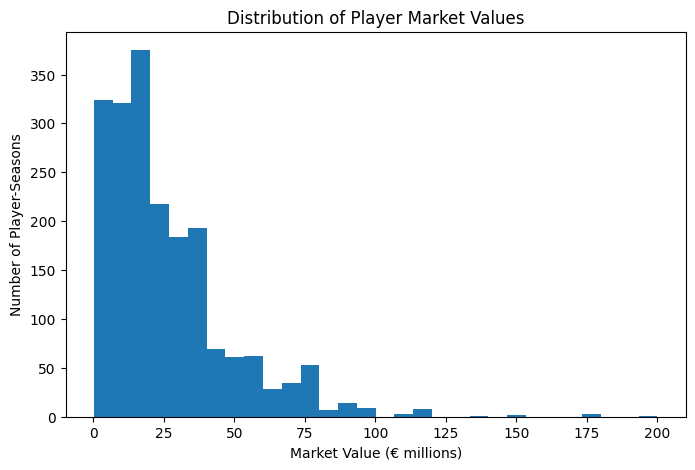

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(all_seasons_clean["market_value"] / 1_000_000, bins=30)
plt.xlabel("Market Value (€ millions)")
plt.ylabel("Number of Player-Seasons")
plt.title("Distribution of Player Market Values")
plt.show()

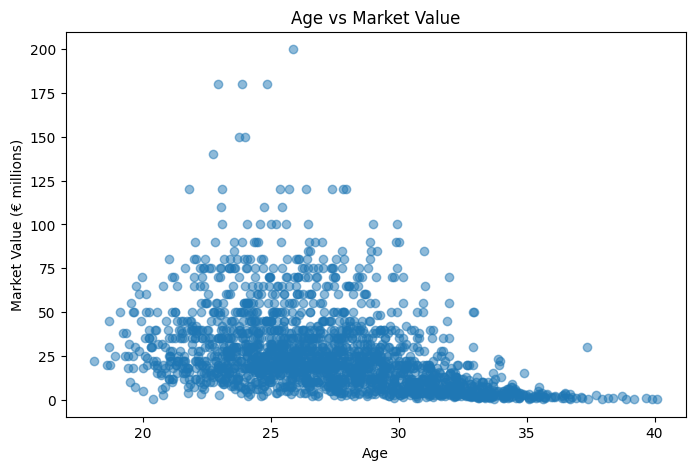

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    all_seasons_clean["age"],
    all_seasons_clean["market_value"] / 1_000_000,
    alpha=0.5
)
plt.xlabel("Age")
plt.ylabel("Market Value (€ millions)")
plt.title("Age vs Market Value")
plt.show()

In [ ]:
numeric_features = [
    "age",
    "gamesPlayed",
    "starts",
    "timePlayed",
    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",
    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",
    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",
    "totalTouchesInOppositionBox_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90",
    "market_value"
]

correlations = (
    all_seasons_clean[numeric_features]
    .corr()["market_value"]
    .sort_values(ascending=False)
)

print(correlations)

market_value                         1.000000
goals_per90                          0.419079
totalTouchesInOppositionBox_per90    0.395909
expectedGoals_per90                  0.388435
expectedAssists_per90                0.387586
totalShots_per90                     0.385220
goalAssists_per90                    0.341938
keyPassesAttemptAssists_per90        0.336209
starts                               0.281696
timePlayed                           0.274994
gamesPlayed                          0.270366
successfulDribbles_per90             0.250995
groundDuelsWon_per90                 0.180035
duelsWon_per90                       0.102003
totalLossesOfPossession_per90        0.054917
tacklesWon_per90                    -0.025008
totalTackles_per90                  -0.026531
aerialDuelsWon_per90                -0.098365
interceptions_per90                 -0.124872
recoveries_per90                    -0.127380
blocks_per90                        -0.185735
totalClearances_per90             

In [ ]:
import numpy as np

all_seasons_clean["age_squared"] = (
    all_seasons_clean["age"] ** 2
)

all_seasons_clean["log_market_value"] = np.log1p(
    all_seasons_clean["market_value"]
)

print(
    all_seasons_clean[
        ["playerName", "age", "age_squared",
         "market_value", "log_market_value"]
    ].head()
)

            playerName        age  age_squared  market_value  log_market_value
0  Alexandre Lacazette  30.031485   901.890108      28000000         17.147715
1           Bernd Leno  29.242984   855.152128      22000000         16.906553
2          Bukayo Saka  19.726215   389.123555      65000000         17.989898
3        Dani Ceballos  24.835044   616.779435      27000000         17.111347
4     Emile Smith Rowe  20.862423   435.240693      18000000         16.705882


In [ ]:
train_data = all_seasons_clean[
    all_seasons_clean["season_label"] != "2025-26"
].copy()

test_data = all_seasons_clean[
    all_seasons_clean["season_label"] == "2025-26"
].copy()

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("\nTraining seasons:")
print(train_data["season_label"].value_counts().sort_index())

print("\nTest seasons:")
print(test_data["season_label"].value_counts())

Training rows: 1634
Testing rows: 336

Training seasons:
season_label
2020-21    322
2021-22    336
2022-23    330
2023-24    336
2024-25    310
Name: count, dtype: int64

Test seasons:
season_label
2025-26    336
Name: count, dtype: int64


In [ ]:
model_features = [
    "position",
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",

    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",

    "totalTouchesInOppositionBox_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90"
]

In [ ]:
X_train = train_data[model_features].copy()
X_test = test_data[model_features].copy()

y_train = train_data["market_value"].copy()
y_test = test_data["market_value"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1634, 24)
X_test: (336, 24)
y_train: (1634,)
y_test: (336,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

categorical_features = ["position"]

numeric_features_model = [
    col for col in model_features
    if col != "position"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_model
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print(f"MAE:  €{mae/1_000_000:.2f}M")
print(f"RMSE: €{rmse/1_000_000:.2f}M")
print(f"R²:   {r2:.3f}")

Linear Regression Results
MAE:  €12.86M
RMSE: €18.70M
R²:   0.410


In [ ]:
# Log targets
y_train_log = np.log1p(train_data["market_value"])
y_test_log = np.log1p(test_data["market_value"])

# Same preprocessing + linear regression
linear_log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_log_model.fit(X_train, y_train_log)

# Predict log market values
y_pred_log = linear_log_model.predict(X_test)

# Convert predictions back to euros
y_pred_log_euros = np.expm1(y_pred_log)

# Evaluate in euros
mae_log = mean_absolute_error(y_test, y_pred_log_euros)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log_euros)
)
r2_log = r2_score(y_test, y_pred_log_euros)

print("Log-Target Linear Regression Results")
print("------------------------------------")
print(f"MAE:  €{mae_log/1_000_000:.2f}M")
print(f"RMSE: €{rmse_log/1_000_000:.2f}M")
print(f"R²:   {r2_log:.3f}")

Log-Target Linear Regression Results
------------------------------------
MAE:  €12.38M
RMSE: €18.60M
R²:   0.417


In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE:  €{mae_rf/1_000_000:.2f}M")
print(f"RMSE: €{rmse_rf/1_000_000:.2f}M")
print(f"R²:   {r2_rf:.3f}")

Random Forest Results
---------------------
MAE:  €11.42M
RMSE: €17.25M
R²:   0.498


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"MAE:  €{mae_xgb/1_000_000:.2f}M")
print(f"RMSE: €{rmse_xgb/1_000_000:.2f}M")
print(f"R²:   {r2_xgb:.3f}")

XGBoost Results
----------------
MAE:  €11.28M
RMSE: €17.16M
R²:   0.504


In [ ]:
print("TRAIN POSITION COUNTS")
print(
    train_data["position"]
    .value_counts()
)

print("\nTEST POSITION COUNTS")
print(
    test_data["position"]
    .value_counts()
)

TRAIN POSITION COUNTS
position
Defender      612
Midfielder    529
Forward       372
Goalkeeper    121
Name: count, dtype: int64

TEST POSITION COUNTS
position
Defender      124
Midfielder    109
Forward        79
Goalkeeper     24
Name: count, dtype: int64


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

position_features = [
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",

    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",

    "totalTouchesInOppositionBox_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90"
]

positions = [
    "Forward",
    "Midfielder",
    "Defender",
    "Goalkeeper"
]

position_results = []
position_models = {}

for pos in positions:

    train_pos = train_data[
        train_data["position"] == pos
    ].copy()

    test_pos = test_data[
        test_data["position"] == pos
    ].copy()

    X_train_pos = train_pos[position_features]
    X_test_pos = test_pos[position_features]

    y_train_pos = train_pos["market_value"]
    y_test_pos = test_pos["market_value"]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_pos, y_train_pos)

    predictions = model.predict(X_test_pos)

    mae = mean_absolute_error(
        y_test_pos,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_pos,
            predictions
        )
    )

    r2 = r2_score(
        y_test_pos,
        predictions
    )

    position_results.append({
        "Position": pos,
        "Train Rows": len(train_pos),
        "Test Rows": len(test_pos),
        "MAE (€M)": mae / 1_000_000,
        "RMSE (€M)": rmse / 1_000_000,
        "R²": r2
    })

    position_models[pos] = model


position_results_df = pd.DataFrame(
    position_results
)

print(position_results_df)

     Position  Train Rows  Test Rows   MAE (€M)  RMSE (€M)        R²
0     Forward         372         79  14.173782  20.535925  0.523855
1  Midfielder         529        109  14.523295  21.333764  0.330283
2    Defender         612        124   9.837702  14.448576  0.336252
3  Goalkeeper         121         24   4.967728   6.825425  0.721610


In [ ]:
all_position_predictions = []
all_position_actuals = []

for pos in positions:

    test_pos = test_data[
        test_data["position"] == pos
    ].copy()

    X_test_pos = test_pos[position_features]

    preds = position_models[pos].predict(X_test_pos)

    all_position_predictions.extend(preds)
    all_position_actuals.extend(
        test_pos["market_value"].values
    )

all_position_predictions = np.array(
    all_position_predictions
)

all_position_actuals = np.array(
    all_position_actuals
)

overall_mae = mean_absolute_error(
    all_position_actuals,
    all_position_predictions
)

overall_rmse = np.sqrt(
    mean_squared_error(
        all_position_actuals,
        all_position_predictions
    )
)

overall_r2 = r2_score(
    all_position_actuals,
    all_position_predictions
)

print("Position-Specific XGBoost Overall")
print("--------------------------------")
print(f"MAE:  €{overall_mae/1_000_000:.2f}M")
print(f"RMSE: €{overall_rmse/1_000_000:.2f}M")
print(f"R²:   {overall_r2:.3f}")

Position-Specific XGBoost Overall
--------------------------------
MAE:  €12.03M
RMSE: €18.09M
R²:   0.448


In [ ]:
candidate_role_features = [
    # Midfield / passing
    "totalPasses",
    "successfulPassesOppositionHalf",
    "successfulPassesOwnHalf",
    "successfulLongPasses",
    "throughBalls",
    "openPlayPasses",
    "touches",
    "secondGoalAssists",

    # Defensive
    "aerialDuels",
    "cleanSheets",
    "goalsConceded",

    # Goalkeeper
    "expectedGoalsOnTargetConceded",
    "penaltyGoalsConceded",
    "putthroughBlockedDistribution",
    "putthroughBlockedDistributionWon"
]

season_dfs = {
    "2020-21": pl_stats_2021,
    "2021-22": pl_stats_2022,
    "2022-23": pl_stats_2023,
    "2023-24": pl_stats_2024,
    "2024-25": pl_stats_2025,
    "2025-26": pl_stats_2026
}

for feature in candidate_role_features:
    present_in = [
        season
        for season, df in season_dfs.items()
        if feature in df.columns
    ]

    print(
        feature,
        "->",
        f"{len(present_in)}/6 seasons",
        present_in
    )

totalPasses -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
successfulPassesOppositionHalf -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
successfulPassesOwnHalf -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
successfulLongPasses -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
throughBalls -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
openPlayPasses -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
touches -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
secondGoalAssists -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
aerialDuels -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
cleanSheets -> 6/6 seasons ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
goalsConceded 

In [ ]:
selected_features_extended = [
    "playerId",
    "playerName",
    "position",
    "team_name",
    "season",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "keyPassesAttemptAssists",
    "successfulDribbles",

    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuelsWon",
    "recoveries",

    "totalLossesOfPossession",
    "totalTouchesInOppositionBox",

    "totalPasses",
    "successfulPassesOppositionHalf",
    "successfulPassesOwnHalf",
    "successfulLongPasses",
    "throughBalls",
    "openPlayPasses",
    "touches",
    "secondGoalAssists",

    "aerialDuels",
    "cleanSheets",
    "goalsConceded",
    "expectedGoalsOnTargetConceded",
    "penaltyGoalsConceded",
    "putthroughBlockedDistribution",
    "putthroughBlockedDistributionWon"
]

def prepare_performance_season_extended(df):
    data = df[selected_features_extended].copy()

    data = data[
        data["timePlayed"] >= 900
    ].copy()

    data = data.fillna(0)

    data["name_normalized"] = (
        data["playerName"].apply(normalize_name)
    )

    return data

In [ ]:
performance_2021_ext = prepare_performance_season_extended(pl_stats_2021)
performance_2022_ext = prepare_performance_season_extended(pl_stats_2022)
performance_2023_ext = prepare_performance_season_extended(pl_stats_2023)
performance_2024_ext = prepare_performance_season_extended(pl_stats_2024)
performance_2025_ext = prepare_performance_season_extended(pl_stats_2025)
performance_2026_ext = prepare_performance_season_extended(pl_stats_2026)

print(performance_2021_ext.shape)
print(performance_2022_ext.shape)
print(performance_2023_ext.shape)
print(performance_2024_ext.shape)
print(performance_2025_ext.shape)
print(performance_2026_ext.shape)

(327, 42)
(345, 42)
(336, 42)
(345, 42)
(319, 42)
(337, 42)


In [ ]:
name_mappings = {

    "2020-21": {
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Gabriel Magalhães": "Gabriel",
        "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
        "Oliver McBurnie": "Oli McBurnie",
        "Robert Brady": "Robbie Brady",
        "Son Heung-Min": "Heung-min Son"
    },

    "2021-22": {
        "Gabriel Magalhães": "Gabriel",
        "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Son Heung-Min": "Heung-min Son",
        "Vitalii Mykolenko": "Vitaliy Mykolenko",
        "Dimitris Giannoulis": "Dimitrios Giannoulis",
        "Samir": "Samir Caetano",
        "Hwang Hee-Chan": "Hee-chan Hwang",
        "Jonny": "Jonny Otto",
        "Trincão": "Francisco Trincão"
    },

    "2022-23": {
        "Gabriel Magalhães": "Gabriel",
        "Vitalii Mykolenko": "Vitaliy Mykolenko",
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Son Heung-Min": "Heung-min Son",
        "Hwang Hee-Chan": "Hee-chan Hwang",
        "Jonny": "Jonny Otto",
        "Max Wöber": "Maximilian Wöber",
        "Rasmus Kristensen": "Rasmus Nissen Kristensen",
        "Charly Alcaraz": "Carlos Alcaraz",
        "Toti Gomes": "Toti"
    },

    "2023-24": {
        "Gabriel Magalhães": "Gabriel",
        "Jóhann Gudmundsson": "Jóhann Berg Gudmundsson",
        "Vitalii Mykolenko": "Vitaliy Mykolenko",
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Oliver McBurnie": "Oli McBurnie",
        "Son Heung-Min": "Heung-min Son",
        "Hwang Hee-Chan": "Hee-chan Hwang",
        "Toti Gomes": "Toti",
        "Ameen Al Dakhil": "Ameen Al-Dakhil",
        "Mykhailo Mudryk": "Mykhaylo Mudryk",
        "Pelly Mpanzu": "Pelly Ruddock Mpanzu",
        "Vinicius Souza": "Vini Souza"
    },

    "2024-25": {
        "Gabriel Magalhães": "Gabriel",
        "Vitalii Mykolenko": "Vitaliy Mykolenko",
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Son Heung-Min": "Heung-min Son",
        "Toti Gomes": "Toti"
    },

    "2025-26": {
        "Gabriel Magalhães": "Gabriel",
        "Vitalii Mykolenko": "Vitaliy Mykolenko",
        "Alisson Becker": "Alisson",
        "Andy Robertson": "Andrew Robertson",
        "Hwang Hee-Chan": "Hee-chan Hwang",
        "Toti Gomes": "Toti",
        "Ferdi Kadioglu": "Ferdi Kadıoğlu",
        "Hannibal Mejbri": "Hannibal",
        "Valentín Castellanos": "Taty Castellanos"
    }
}

In [ ]:
players_to_drop = {

    "2020-21": [
        "David Luiz",
        "Roberto Firmino",
        "Christian Benteke",
        "Gareth Bale",
        "Mbaye Diagne"
    ],

    "2021-22": [
        "Álvaro Fernández",
        "Roberto Firmino",
        "Teemu Pukki",
        "Christian Benteke"
    ],

    "2022-23": [
        "Roberto Firmino"
    ],

    "2023-24": [
        "Illia Zabarnyi",
        "Ben Brereton"
    ],

    "2024-25": [
        "Illia Zabarnyi",
        "Yehor Yarmoliuk",
        "Sam Szmodics",
        "Caleb Okoli"
    ],

    "2025-26": [
        "Yehor Yarmoliuk"
    ]
}

In [ ]:
season_perf_ext = {
    "2020-21": performance_2021_ext,
    "2021-22": performance_2022_ext,
    "2022-23": performance_2023_ext,
    "2023-24": performance_2024_ext,
    "2024-25": performance_2025_ext,
    "2025-26": performance_2026_ext
}

for season_label, df in season_perf_ext.items():

    df["tm_name"] = (
        df["playerName"]
        .replace(name_mappings[season_label])
    )

    df.drop(
        df[
            df["playerName"].isin(
                players_to_drop[season_label]
            )
        ].index,
        inplace=True
    )

    df["tm_name_normalized"] = (
        df["tm_name"].apply(normalize_name)
    )

    print(
        season_label,
        "final players:",
        len(df)
    )

2020-21 final players: 322
2021-22 final players: 341
2022-23 final players: 335
2023-24 final players: 343
2024-25 final players: 315
2025-26 final players: 336


In [ ]:
correct_duplicate_ids = {

    "2020-21": {
        "ben davies": 192765
    },

    "2021-22": {
        "ben davies": 192765,
        "reece james": 472423
    },

    "2022-23": {
        "adam smith": 61841,
        "danny ward": 203026,
        "reece james": 472423
    },

    "2023-24": {},

    "2024-25": {
        "joao pedro": 626724
    },

    "2025-26": {}
}

In [ ]:
per90_features = [
    "goals",
    "goalAssists",
    "totalShots",
    "expectedGoals",
    "expectedAssists",
    "keyPassesAttemptAssists",
    "successfulDribbles",
    "totalTouchesInOppositionBox",

    "totalTackles",
    "tacklesWon",
    "interceptions",
    "blocks",
    "totalClearances",
    "duelsWon",
    "groundDuelsWon",
    "aerialDuels",
    "aerialDuelsWon",
    "recoveries",

    "totalLossesOfPossession",

    "totalPasses",
    "successfulPassesOppositionHalf",
    "successfulPassesOwnHalf",
    "successfulLongPasses",
    "throughBalls",
    "openPlayPasses",
    "touches",
    "secondGoalAssists",

    "cleanSheets",
    "goalsConceded",
    "expectedGoalsOnTargetConceded",
    "penaltyGoalsConceded",
    "putthroughBlockedDistribution",
    "putthroughBlockedDistributionWon"
]

In [ ]:
def build_season_dataset(
    performance_df,
    season_label,
    start_date,
    end_date
):

    data = performance_df.copy()

    tm = pl_data[
        (pl_data["date"] >= start_date) &
        (pl_data["date"] <= end_date)
    ].copy()

    tm_latest = (
        tm
        .sort_values("date")
        .groupby("player_id")
        .tail(1)
        .copy()
    )

    tm_lookup = tm_latest[
        [
            "player_id",
            "name",
            "name_normalized",
            "market_value",
            "date",
            "date_of_birth"
        ]
    ].copy()

    tm_lookup = tm_lookup.rename(
        columns={
            "name": "tm_name_transfermarkt",
            "date": "valuation_date"
        }
    )

    # Resolve known ambiguous names
    for norm_name, correct_id in correct_duplicate_ids[season_label].items():

        tm_lookup = tm_lookup[
            ~(
                (tm_lookup["name_normalized"] == norm_name) &
                (tm_lookup["player_id"] != correct_id)
            )
        ].copy()

    # Remove remaining duplicate names only if they are irrelevant
    relevant_names = set(
        data["tm_name_normalized"]
    )

    duplicate_names = (
        tm_lookup[
            tm_lookup["name_normalized"]
            .duplicated(keep=False)
        ]["name_normalized"]
        .unique()
    )

    for duplicate_name in duplicate_names:

        if duplicate_name not in relevant_names:

            tm_lookup = tm_lookup[
                tm_lookup["name_normalized"] != duplicate_name
            ].copy()

    # Merge
    merged = data.merge(
        tm_lookup,
        left_on="tm_name_normalized",
        right_on="name_normalized",
        how="inner"
    )

    # Datetime
    merged["valuation_date"] = pd.to_datetime(
        merged["valuation_date"]
    )

    merged["date_of_birth"] = pd.to_datetime(
        merged["date_of_birth"]
    )

    # Age at valuation date
    merged["age"] = (
        (
            merged["valuation_date"]
            - merged["date_of_birth"]
        ).dt.days / 365.25
    )

    # Per-90 features
    for col in per90_features:

        merged[col + "_per90"] = (
            merged[col] /
            merged["timePlayed"]
        ) * 90

    merged["season_label"] = season_label

    return merged

In [ ]:
merged_2021_ext = build_season_dataset(
    performance_2021_ext,
    "2020-21",
    "2020-08-01",
    "2021-06-30"
)

merged_2022_ext = build_season_dataset(
    performance_2022_ext,
    "2021-22",
    "2021-08-01",
    "2022-06-30"
)

merged_2023_ext = build_season_dataset(
    performance_2023_ext,
    "2022-23",
    "2022-08-01",
    "2023-06-30"
)

merged_2024_ext = build_season_dataset(
    performance_2024_ext,
    "2023-24",
    "2023-08-01",
    "2024-06-30"
)

merged_2025_ext = build_season_dataset(
    performance_2025_ext,
    "2024-25",
    "2024-08-01",
    "2025-06-30"
)

merged_2026_ext = build_season_dataset(
    performance_2026_ext,
    "2025-26",
    "2025-08-01",
    "2026-06-30"
)

for season, df in {
    "2020-21": merged_2021_ext,
    "2021-22": merged_2022_ext,
    "2022-23": merged_2023_ext,
    "2023-24": merged_2024_ext,
    "2024-25": merged_2025_ext,
    "2025-26": merged_2026_ext
}.items():

    print(
        season,
        df.shape,
        "missing ages:",
        df["age"].isna().sum()
    )

2020-21 (322, 85) missing ages: 0
2021-22 (341, 85) missing ages: 0
2022-23 (335, 85) missing ages: 0
2023-24 (343, 85) missing ages: 0
2024-25 (311, 85) missing ages: 0
2025-26 (336, 85) missing ages: 0


In [ ]:
base_columns = [
    "player_id",
    "playerName",
    "team_name",
    "position",
    "season_label",
    "age",
    "gamesPlayed",
    "starts",
    "timePlayed",
    "market_value",
    "valuation_date"
]

per90_columns = [
    col + "_per90"
    for col in per90_features
]

final_columns = (
    base_columns
    + per90_columns
)

all_seasons_ext = pd.concat(
    [
        merged_2021_ext[final_columns],
        merged_2022_ext[final_columns],
        merged_2023_ext[final_columns],
        merged_2024_ext[final_columns],
        merged_2025_ext[final_columns],
        merged_2026_ext[final_columns]
    ],
    ignore_index=True
)

print("Combined shape:", all_seasons_ext.shape)

print("\nRows per season:")
print(
    all_seasons_ext["season_label"]
    .value_counts()
    .sort_index()
)

print(
    "\nDuplicate player-seasons:",
    all_seasons_ext.duplicated(
        subset=["player_id", "season_label"]
    ).sum()
)

Combined shape: (1988, 44)

Rows per season:
season_label
2020-21    322
2021-22    341
2022-23    335
2023-24    343
2024-25    311
2025-26    336
Name: count, dtype: int64

Duplicate player-seasons: 18


In [ ]:
team_names_combined = (
    all_seasons_ext
    .groupby(
        ["player_id", "season_label"]
    )["team_name"]
    .apply(
        lambda x: " / ".join(sorted(set(x)))
    )
    .reset_index()
)

all_seasons_clean = (
    all_seasons_ext
    .drop(columns=["team_name"])
    .drop_duplicates(
        subset=["player_id", "season_label"]
    )
)

all_seasons_clean = all_seasons_clean.merge(
    team_names_combined,
    on=["player_id", "season_label"],
    how="left"
)

print("Clean master shape:", all_seasons_clean.shape)

print(
    "Duplicate player-seasons:",
    all_seasons_clean.duplicated(
        subset=["player_id", "season_label"]
    ).sum()
)

print("\nRows per season:")
print(
    all_seasons_clean["season_label"]
    .value_counts()
    .sort_index()
)

Clean master shape: (1970, 44)
Duplicate player-seasons: 0

Rows per season:
season_label
2020-21    322
2021-22    336
2022-23    330
2023-24    336
2024-25    310
2025-26    336
Name: count, dtype: int64


In [ ]:
# Copy before feature engineering
model_data = all_seasons_clean.copy()

# --------------------------------------------------
# 1. PASSING / MIDFIELD FEATURES
# --------------------------------------------------

# Share of passes completed in opposition half
model_data["opp_half_pass_share"] = (
    model_data["successfulPassesOppositionHalf_per90"] /
    model_data["totalPasses_per90"].replace(0, np.nan)
)

# Share of passes completed in own half
model_data["own_half_pass_share"] = (
    model_data["successfulPassesOwnHalf_per90"] /
    model_data["totalPasses_per90"].replace(0, np.nan)
)

# Long-pass tendency
model_data["long_pass_share"] = (
    model_data["successfulLongPasses_per90"] /
    model_data["totalPasses_per90"].replace(0, np.nan)
)

# --------------------------------------------------
# 2. DEFENSIVE FEATURES
# --------------------------------------------------

# Tackle success rate
model_data["tackle_win_rate"] = (
    model_data["tacklesWon_per90"] /
    model_data["totalTackles_per90"].replace(0, np.nan)
)

# Aerial duel success rate
model_data["aerial_win_rate"] = (
    model_data["aerialDuelsWon_per90"] /
    model_data["aerialDuels_per90"].replace(0, np.nan)
)

# --------------------------------------------------
# 3. GOALKEEPER FEATURES
# --------------------------------------------------

# Reconstruct clean sheets from per-90 data,
# then calculate proportion of appearances with a clean sheet
clean_sheets_raw = (
    model_data["cleanSheets_per90"] *
    model_data["timePlayed"] / 90
)

model_data["clean_sheet_rate"] = (
    clean_sheets_raw /
    model_data["gamesPlayed"].replace(0, np.nan)
)

# Shot-stopping proxy:
# positive = conceded fewer goals than expected from shots on target
model_data["shot_stopping_overperformance"] = (
    model_data["expectedGoalsOnTargetConceded_per90"] -
    model_data["goalsConceded_per90"]
)

# Distribution success rate
model_data["gk_distribution_success_rate"] = (
    model_data["putthroughBlockedDistributionWon_per90"] /
    model_data["putthroughBlockedDistribution_per90"].replace(0, np.nan)
)

# --------------------------------------------------
# 4. CLEAN UP
# --------------------------------------------------

engineered_features = [
    "opp_half_pass_share",
    "own_half_pass_share",
    "long_pass_share",
    "tackle_win_rate",
    "aerial_win_rate",
    "clean_sheet_rate",
    "shot_stopping_overperformance",
    "gk_distribution_success_rate"
]

model_data[engineered_features] = (
    model_data[engineered_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(
    model_data[engineered_features]
    .describe()
    .T
)

                                count      mean       std       min       25%  \
opp_half_pass_share            1970.0  0.421678  0.145594  0.021866  0.333970   
own_half_pass_share            1970.0  0.389904  0.145669  0.084746  0.273835   
long_pass_share                1970.0  0.048478  0.045883  0.000000  0.024134   
tackle_win_rate                1970.0  0.561799  0.169936  0.000000  0.500000   
aerial_win_rate                1970.0  0.498864  0.183319  0.000000  0.375000   
clean_sheet_rate               1970.0  0.149014  0.115926  0.000000  0.055556   
shot_stopping_overperformance  1970.0 -0.098295  0.271337 -2.518837 -0.202402   
gk_distribution_success_rate   1970.0  0.450821  0.182776  0.000000  0.354167   

                                    50%       75%       max  
opp_half_pass_share            0.448997  0.523190  0.762542  
own_half_pass_share            0.376945  0.482028  0.858333  
long_pass_share                0.036586  0.053000  0.356297  
tackle_win_rate       

In [ ]:
model_data["age_squared"] = model_data["age"] ** 2

In [ ]:
forward_features = [
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",
    "totalTouchesInOppositionBox_per90",

    "touches_per90",
    "secondGoalAssists_per90",

    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",
    "totalLossesOfPossession_per90"
]

In [ ]:
midfielder_features = [
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    # Attack / creativity
    "goals_per90",
    "goalAssists_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",
    "secondGoalAssists_per90",

    # Passing
    "totalPasses_per90",
    "successfulPassesOppositionHalf_per90",
    "successfulPassesOwnHalf_per90",
    "successfulLongPasses_per90",
    "throughBalls_per90",
    "openPlayPasses_per90",
    "touches_per90",

    # Passing style
    "opp_half_pass_share",
    "own_half_pass_share",
    "long_pass_share",

    # Defensive / possession
    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "duelsWon_per90",
    "groundDuelsWon_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90"
]

In [ ]:
defender_features = [
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    # Defensive
    "totalTackles_per90",
    "tacklesWon_per90",
    "tackle_win_rate",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuels_per90",
    "aerialDuelsWon_per90",
    "aerial_win_rate",
    "recoveries_per90",

    # Ball playing
    "totalPasses_per90",
    "successfulPassesOwnHalf_per90",
    "successfulPassesOppositionHalf_per90",
    "successfulLongPasses_per90",
    "openPlayPasses_per90",
    "touches_per90",

    "own_half_pass_share",
    "opp_half_pass_share",
    "long_pass_share",

    # Some attacking contribution
    "goalAssists_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",

    "totalLossesOfPossession_per90"
]

In [ ]:
goalkeeper_features = [
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    # Shot stopping
    "cleanSheets_per90",
    "clean_sheet_rate",
    "goalsConceded_per90",
    "expectedGoalsOnTargetConceded_per90",
    "shot_stopping_overperformance",
    "penaltyGoalsConceded_per90",

    # Distribution
    "putthroughBlockedDistribution_per90",
    "putthroughBlockedDistributionWon_per90",
    "gk_distribution_success_rate",

    "totalPasses_per90",
    "successfulLongPasses_per90",
    "openPlayPasses_per90",
    "touches_per90",
    "long_pass_share"
]

In [ ]:
position_feature_sets = {
    "Forward": forward_features,
    "Midfielder": midfielder_features,
    "Defender": defender_features,
    "Goalkeeper": goalkeeper_features
}

In [ ]:
train_data_pos = model_data[
    model_data["season_label"] != "2025-26"
].copy()

test_data_pos = model_data[
    model_data["season_label"] == "2025-26"
].copy()

print("Training:", len(train_data_pos))
print("Testing:", len(test_data_pos))

print("\nTrain positions:")
print(train_data_pos["position"].value_counts())

print("\nTest positions:")
print(test_data_pos["position"].value_counts())

Training: 1634
Testing: 336

Train positions:
position
Defender      612
Midfielder    529
Forward       372
Goalkeeper    121
Name: count, dtype: int64

Test positions:
position
Defender      124
Midfielder    109
Forward        79
Goalkeeper     24
Name: count, dtype: int64


In [ ]:
tailored_results = []
tailored_models = {}

all_tailored_predictions = []
all_tailored_actuals = []

for pos, features in position_feature_sets.items():

    train_pos = train_data_pos[
        train_data_pos["position"] == pos
    ].copy()

    test_pos = test_data_pos[
        test_data_pos["position"] == pos
    ].copy()

    X_train_pos = train_pos[features]
    X_test_pos = test_pos[features]

    y_train_pos = train_pos["market_value"]
    y_test_pos = test_pos["market_value"]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_pos, y_train_pos)

    preds = model.predict(X_test_pos)

    mae = mean_absolute_error(
        y_test_pos,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_pos,
            preds
        )
    )

    r2 = r2_score(
        y_test_pos,
        preds
    )

    tailored_results.append({
        "Position": pos,
        "Features": len(features),
        "Train Rows": len(train_pos),
        "Test Rows": len(test_pos),
        "MAE (€M)": mae / 1_000_000,
        "RMSE (€M)": rmse / 1_000_000,
        "R²": r2
    })

    tailored_models[pos] = model

    all_tailored_predictions.extend(preds)
    all_tailored_actuals.extend(
        y_test_pos.values
    )


tailored_results_df = pd.DataFrame(
    tailored_results
)

print(tailored_results_df)

     Position  Features  Train Rows  Test Rows   MAE (€M)  RMSE (€M)        R²
0     Forward        18         372         79  13.673854  19.669842  0.563170
1  Midfielder        29         529        109  10.439984  15.896472  0.628159
2    Defender        30         612        124   8.150422  12.039272  0.539156
3  Goalkeeper        19         121         24   4.388231   5.949199  0.788500


In [ ]:
all_tailored_predictions = np.array(
    all_tailored_predictions
)

all_tailored_actuals = np.array(
    all_tailored_actuals
)

tailored_mae = mean_absolute_error(
    all_tailored_actuals,
    all_tailored_predictions
)

tailored_rmse = np.sqrt(
    mean_squared_error(
        all_tailored_actuals,
        all_tailored_predictions
    )
)

tailored_r2 = r2_score(
    all_tailored_actuals,
    all_tailored_predictions
)

print("\nTailored Position-Specific XGBoost")
print(f"MAE:  €{tailored_mae/1_000_000:.2f}M")
print(f"RMSE: €{tailored_rmse/1_000_000:.2f}M")
print(f"R²:   {tailored_r2:.3f}")


Tailored Position-Specific XGBoost
MAE:  €9.92M
RMSE: €15.13M
R²:   0.614


In [ ]:
print(
    tailored_results_df[
        [
            "Position",
            "Features",
            "Train Rows",
            "Test Rows",
            "MAE (€M)",
            "RMSE (€M)",
            "R²"
        ]
    ]
)

     Position  Features  Train Rows  Test Rows   MAE (€M)  RMSE (€M)        R²
0     Forward        18         372         79  13.673854  19.669842  0.563170
1  Midfielder        29         529        109  10.439984  15.896472  0.628159
2    Defender        30         612        124   8.150422  12.039272  0.539156
3  Goalkeeper        19         121         24   4.388231   5.949199  0.788500


In [ ]:
position_importance_tables = {}

for pos, model in tailored_models.items():

    features = position_feature_sets[pos]

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": features,
        "importance": importances
    }).sort_values(
        "importance",
        ascending=False
    )

    position_importance_tables[pos] = importance_df

    print("\n" + "=" * 50)
    print(pos.upper())
    print("=" * 50)

    print(
        importance_df.head(15).to_string(
            index=False
        )
    )


FORWARD
                          feature  importance
totalTouchesInOppositionBox_per90    0.206225
                       timePlayed    0.112657
                      goals_per90    0.077250
                           starts    0.066503
    totalLossesOfPossession_per90    0.061819
            expectedAssists_per90    0.059067
              expectedGoals_per90    0.057189
                    touches_per90    0.053653
                              age    0.040417
                      age_squared    0.040271
             groundDuelsWon_per90    0.040217
                 totalShots_per90    0.038078
                goalAssists_per90    0.033708
    keyPassesAttemptAssists_per90    0.031079
             aerialDuelsWon_per90    0.022690

MIDFIELDER
                             feature  importance
successfulPassesOppositionHalf_per90    0.147544
                 opp_half_pass_share    0.076099
                          timePlayed    0.070072
                         age_squared    0.06285

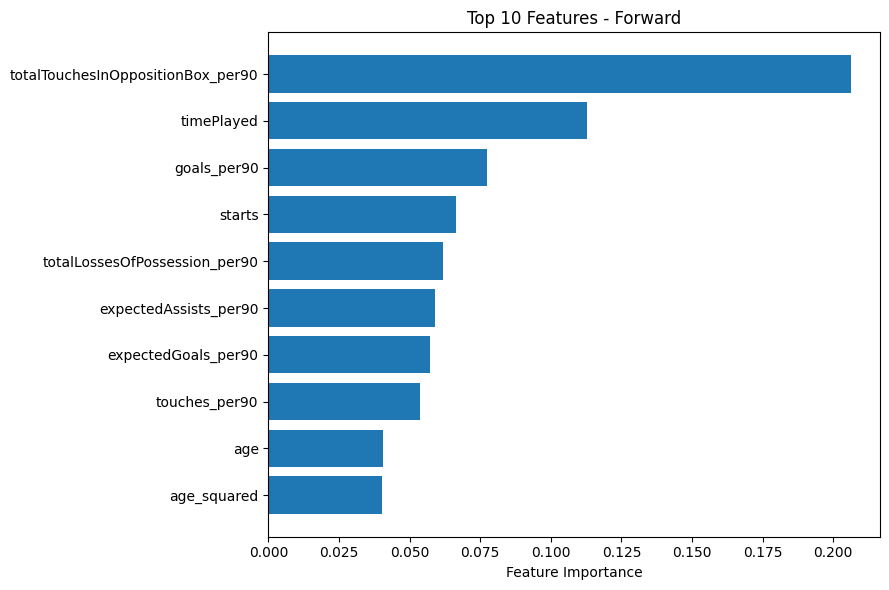

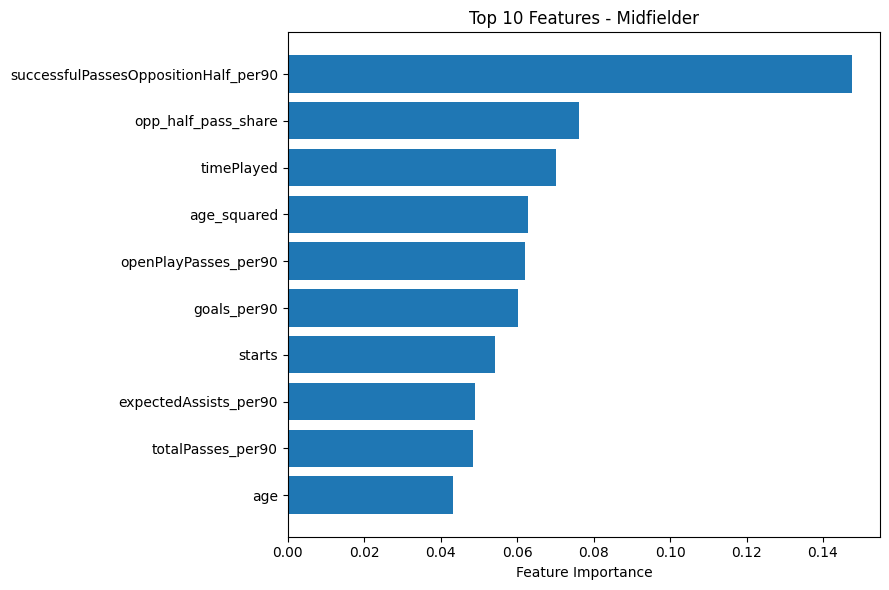

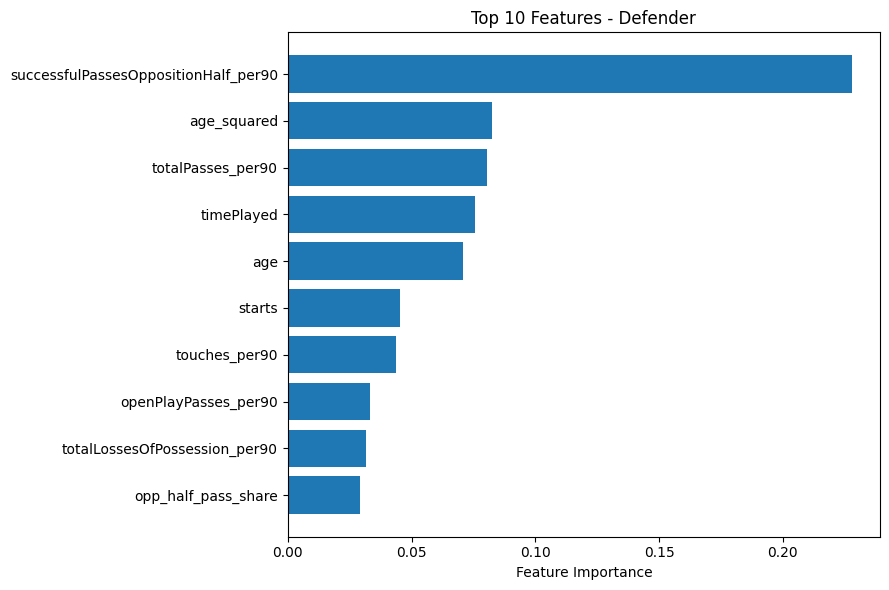

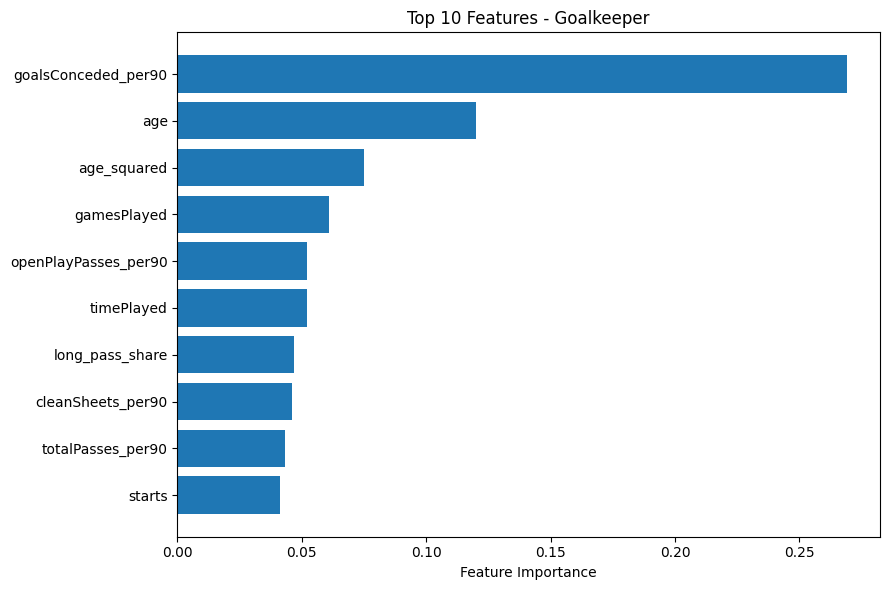

In [ ]:
for pos, importance_df in position_importance_tables.items():

    top10 = importance_df.head(10)

    plt.figure(figsize=(9, 6))

    plt.barh(
        top10["feature"][::-1],
        top10["importance"][::-1]
    )

    plt.xlabel("Feature Importance")
    plt.title(
        f"Top 10 Features - {pos}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.02, 0.03, 0.05],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [ ]:
mid_train = train_data_pos[
    train_data_pos["position"] == "Midfielder"
].copy()

mid_test = test_data_pos[
    test_data_pos["position"] == "Midfielder"
].copy()

X_mid_train = mid_train[midfielder_features]
y_mid_train = mid_train["market_value"]

X_mid_test = mid_test[midfielder_features]
y_mid_test = mid_test["market_value"]

In [ ]:
mid_param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.02, 0.03, 0.05],
    "subsample": [0.8, 1.0]
}

In [ ]:
mid_grid = GridSearchCV(
    estimator=XGBRegressor(
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=mid_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

mid_grid.fit(
    X_mid_train,
    y_mid_train
)

print("Best parameters:")
print(mid_grid.best_params_)

print(
    "Best CV MAE:",
    -mid_grid.best_score_ / 1_000_000,
    "€M"
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters:
{'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best CV MAE: 10.236342800000001 €M


In [ ]:
best_mid_model = mid_grid.best_estimator_

mid_pred = best_mid_model.predict(
    X_mid_test
)

mid_mae = mean_absolute_error(
    y_mid_test,
    mid_pred
)

mid_rmse = np.sqrt(
    mean_squared_error(
        y_mid_test,
        mid_pred
    )
)

mid_r2 = r2_score(
    y_mid_test,
    mid_pred
)

print("Tuned Midfielder Model")
print("----------------------")
print(f"MAE:  €{mid_mae/1_000_000:.2f}M")
print(f"RMSE: €{mid_rmse/1_000_000:.2f}M")
print(f"R²:   {mid_r2:.3f}")

Tuned Midfielder Model
----------------------
MAE:  €10.12M
RMSE: €15.68M
R²:   0.638


In [ ]:
mid_train_time = train_data_pos[
    train_data_pos["position"] == "Midfielder"
].copy().reset_index(drop=True)

X_mid_train_time = mid_train_time[midfielder_features]
y_mid_train_time = mid_train_time["market_value"]

season_order = [
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25"
]

time_cv_splits = []

for i in range(1, len(season_order)):

    training_seasons = season_order[:i]
    validation_season = season_order[i]

    train_idx = mid_train_time.index[
        mid_train_time["season_label"].isin(training_seasons)
    ].to_numpy()

    val_idx = mid_train_time.index[
        mid_train_time["season_label"] == validation_season
    ].to_numpy()

    time_cv_splits.append(
        (train_idx, val_idx)
    )

    print(
        f"Train: {training_seasons} → "
        f"Validate: {validation_season} | "
        f"{len(train_idx)} train, {len(val_idx)} validation"
    )

Train: ['2020-21'] → Validate: 2021-22 | 107 train, 114 validation
Train: ['2020-21', '2021-22'] → Validate: 2022-23 | 221 train, 101 validation
Train: ['2020-21', '2021-22', '2022-23'] → Validate: 2023-24 | 322 train, 108 validation
Train: ['2020-21', '2021-22', '2022-23', '2023-24'] → Validate: 2024-25 | 430 train, 99 validation


In [ ]:
mid_grid_time = GridSearchCV(
    estimator=XGBRegressor(
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    param_grid={
        "n_estimators": [300, 500, 700],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.02, 0.03, 0.05],
        "subsample": [0.8, 1.0]
    },

    scoring="neg_mean_absolute_error",
    cv=time_cv_splits,
    n_jobs=-1,
    verbose=1
)

mid_grid_time.fit(
    X_mid_train_time,
    y_mid_train_time
)

print("Best parameters:")
print(mid_grid_time.best_params_)

print(
    "Season-CV MAE:",
    -mid_grid_time.best_score_ / 1_000_000,
    "€M"
)

Fitting 4 folds for each of 54 candidates, totalling 216 fits
Best parameters:
{'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Season-CV MAE: 10.6301865 €M


In [ ]:
best_mid_time_model = mid_grid_time.best_estimator_

mid_test = test_data_pos[
    test_data_pos["position"] == "Midfielder"
].copy()

X_mid_test = mid_test[midfielder_features]
y_mid_test = mid_test["market_value"]

mid_pred_time = best_mid_time_model.predict(
    X_mid_test
)

print("Season-Tuned Midfielder Model")
print("-----------------------------")

print(
    f"MAE:  €{mean_absolute_error(y_mid_test, mid_pred_time)/1_000_000:.2f}M"
)

print(
    f"RMSE: €{np.sqrt(mean_squared_error(y_mid_test, mid_pred_time))/1_000_000:.2f}M"
)

print(
    f"R²:   {r2_score(y_mid_test, mid_pred_time):.3f}"
)

Season-Tuned Midfielder Model
-----------------------------
MAE:  €10.38M
RMSE: €16.15M
R²:   0.616


In [ ]:
XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
print("Best season-CV parameters:")
print(mid_grid_time.best_params_)

print(
    "Season-CV MAE:",
    -mid_grid_time.best_score_ / 1_000_000,
    "€M"
)

Best season-CV parameters:
{'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Season-CV MAE: 10.6301865 €M


In [ ]:
development_data = model_data[
    model_data["season_label"].isin([
        "2020-21",
        "2021-22",
        "2022-23",
        "2023-24"
    ])
].copy()

validation_data = model_data[
    model_data["season_label"] == "2024-25"
].copy()

final_test_data = model_data[
    model_data["season_label"] == "2025-26"
].copy()

print("Development rows:", len(development_data))
print("Validation rows:", len(validation_data))
print("Final test rows:", len(final_test_data))

print("\nDevelopment seasons:")
print(
    development_data["season_label"]
    .value_counts()
    .sort_index()
)

print("\nValidation season:")
print(validation_data["season_label"].value_counts())

print("\nFinal test season:")
print(final_test_data["season_label"].value_counts())

Development rows: 1324
Validation rows: 310
Final test rows: 336

Development seasons:
season_label
2020-21    322
2021-22    336
2022-23    330
2023-24    336
Name: count, dtype: int64

Validation season:
season_label
2024-25    310
Name: count, dtype: int64

Final test season:
season_label
2025-26    336
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import GridSearchCV

development_seasons = [
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24"
]

position_param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.02, 0.03, 0.05],
    "subsample": [0.8, 1.0]
}


def tune_position_model(position, features):

    # -----------------------------
    # DEVELOPMENT DATA
    # -----------------------------
    dev = development_data[
        development_data["position"] == position
    ].copy().reset_index(drop=True)

    X_dev = dev[features]
    y_dev = dev["market_value"]

    # -----------------------------
    # EXPANDING TIME CV
    # -----------------------------
    cv_splits = []

    for i in range(1, len(development_seasons)):

        train_seasons = development_seasons[:i]
        val_season = development_seasons[i]

        train_idx = dev.index[
            dev["season_label"].isin(train_seasons)
        ].to_numpy()

        val_idx = dev.index[
            dev["season_label"] == val_season
        ].to_numpy()

        cv_splits.append(
            (train_idx, val_idx)
        )

    # -----------------------------
    # GRID SEARCH
    # -----------------------------
    grid = GridSearchCV(
        estimator=XGBRegressor(
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ),
        param_grid=position_param_grid,
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(
        X_dev,
        y_dev
    )

    # -----------------------------
    # 2024-25 VALIDATION
    # -----------------------------
    val = validation_data[
        validation_data["position"] == position
    ].copy()

    X_val = val[features]
    y_val = val["market_value"]

    preds = grid.best_estimator_.predict(
        X_val
    )

    mae = mean_absolute_error(
        y_val,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            preds
        )
    )

    r2 = r2_score(
        y_val,
        preds
    )

    result = {
        "Position": position,
        "Dev Rows": len(dev),
        "Validation Rows": len(val),
        "CV MAE (€M)": -grid.best_score_ / 1_000_000,
        "Validation MAE (€M)": mae / 1_000_000,
        "Validation RMSE (€M)": rmse / 1_000_000,
        "Validation R²": r2,
        "Best Parameters": grid.best_params_
    }

    return grid.best_estimator_, result

In [ ]:
final_candidate_models = {}
validation_results = []

for position, features in position_feature_sets.items():

    print("Tuning:", position)

    model, result = tune_position_model(
        position,
        features
    )

    final_candidate_models[position] = model
    validation_results.append(result)


validation_results_df = pd.DataFrame(
    validation_results
)

print(
    validation_results_df[
        [
            "Position",
            "Dev Rows",
            "Validation Rows",
            "CV MAE (€M)",
            "Validation MAE (€M)",
            "Validation RMSE (€M)",
            "Validation R²"
        ]
    ]
)

Tuning: Forward
Tuning: Midfielder
Tuning: Defender
Tuning: Goalkeeper
     Position  Dev Rows  Validation Rows  CV MAE (€M)  Validation MAE (€M)  \
0     Forward       299               73    12.145585            14.734660   
1  Midfielder       430               99    10.261975            11.772602   
2    Defender       498              114     7.382870             7.673439   
3  Goalkeeper        97               24     5.447775             4.714287   

   Validation RMSE (€M)  Validation R²  
0             22.782995       0.402515  
1             17.636979       0.494916  
2             10.819868       0.651394  
3              5.829673       0.635343  


In [ ]:
for result in validation_results:

    print("\n", result["Position"])
    print(result["Best Parameters"])




 Forward
{'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}

 Midfielder
{'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 700, 'subsample': 0.8}

 Defender
{'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}

 Goalkeeper
{'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}


In [ ]:
validation_predictions = []
validation_actuals = []

for position, features in position_feature_sets.items():

    val_pos = validation_data[
        validation_data["position"] == position
    ].copy()

    X_val_pos = val_pos[features]
    y_val_pos = val_pos["market_value"]

    preds = final_candidate_models[position].predict(
        X_val_pos
    )

    validation_predictions.extend(preds)
    validation_actuals.extend(
        y_val_pos.values
    )

validation_predictions = np.array(
    validation_predictions
)

validation_actuals = np.array(
    validation_actuals
)

validation_mae = mean_absolute_error(
    validation_actuals,
    validation_predictions
)

validation_rmse = np.sqrt(
    mean_squared_error(
        validation_actuals,
        validation_predictions
    )
)

validation_r2 = r2_score(
    validation_actuals,
    validation_predictions
)

print("Combined Position-Specific Validation")
print(f"MAE:  €{validation_mae/1_000_000:.2f}M")
print(f"RMSE: €{validation_rmse/1_000_000:.2f}M")
print(f"R²:   {validation_r2:.3f}")

Combined Position-Specific Validation
MAE:  €10.42M
RMSE: €16.35M
R²:   0.532


In [ ]:
global_features = [
    "position",
    "age",
    "age_squared",
    "gamesPlayed",
    "starts",
    "timePlayed",

    # Attacking
    "goals_per90",
    "goalAssists_per90",
    "totalShots_per90",
    "expectedGoals_per90",
    "expectedAssists_per90",
    "keyPassesAttemptAssists_per90",
    "successfulDribbles_per90",
    "totalTouchesInOppositionBox_per90",

    # Defensive
    "totalTackles_per90",
    "tacklesWon_per90",
    "interceptions_per90",
    "blocks_per90",
    "totalClearances_per90",

    # Duel / possession
    "duelsWon_per90",
    "groundDuelsWon_per90",
    "aerialDuelsWon_per90",
    "recoveries_per90",
    "totalLossesOfPossession_per90"
]

print("Number of global features:", len(global_features))

Number of global features: 24


In [ ]:
# Development and validation sets for global model
X_dev_global = development_data[global_features].copy()
y_dev_global = development_data["market_value"].copy()

X_val_global = validation_data[global_features].copy()
y_val_global = validation_data["market_value"].copy()

# Same preprocessing as before
categorical_features = ["position"]

numeric_features_global = [
    col for col in global_features
    if col != "position"
]

global_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_global
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

global_validation_model = Pipeline(
    steps=[
        ("preprocessor", global_preprocessor),

        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

global_validation_model.fit(
    X_dev_global,
    y_dev_global
)

global_val_pred = global_validation_model.predict(
    X_val_global
)

global_val_mae = mean_absolute_error(
    y_val_global,
    global_val_pred
)

global_val_rmse = np.sqrt(
    mean_squared_error(
        y_val_global,
        global_val_pred
    )
)

global_val_r2 = r2_score(
    y_val_global,
    global_val_pred
)

print("Global XGBoost - 2024-25 Validation")
print("-----------------------------------")
print(f"MAE:  €{global_val_mae/1_000_000:.2f}M")
print(f"RMSE: €{global_val_rmse/1_000_000:.2f}M")
print(f"R²:   {global_val_r2:.3f}")

Global XGBoost - 2024-25 Validation
-----------------------------------
MAE:  €10.80M
RMSE: €15.88M
R²:   0.559


In [ ]:
print("age_squared" in development_data.columns)
print("age_squared" in validation_data.columns)

True
True


In [ ]:
position_comparison = []

for pos in ["Forward", "Midfielder", "Defender", "Goalkeeper"]:

    val_pos = validation_data[
        validation_data["position"] == pos
    ].copy()

    # -----------------------------
    # GLOBAL MODEL
    # -----------------------------
    X_global_pos = val_pos[global_features]

    global_preds_pos = global_validation_model.predict(
        X_global_pos
    )

    global_mae_pos = mean_absolute_error(
        val_pos["market_value"],
        global_preds_pos
    )

    global_rmse_pos = np.sqrt(
        mean_squared_error(
            val_pos["market_value"],
            global_preds_pos
        )
    )

    global_r2_pos = r2_score(
        val_pos["market_value"],
        global_preds_pos
    )

    # -----------------------------
    # POSITION-SPECIFIC MODEL
    # -----------------------------
    features = position_feature_sets[pos]

    X_tailored_pos = val_pos[features]

    tailored_preds_pos = final_candidate_models[pos].predict(
        X_tailored_pos
    )

    tailored_mae_pos = mean_absolute_error(
        val_pos["market_value"],
        tailored_preds_pos
    )

    tailored_rmse_pos = np.sqrt(
        mean_squared_error(
            val_pos["market_value"],
            tailored_preds_pos
        )
    )

    tailored_r2_pos = r2_score(
        val_pos["market_value"],
        tailored_preds_pos
    )

    position_comparison.append({
        "Position": pos,

        "Global MAE (€M)": global_mae_pos / 1_000_000,
        "Tailored MAE (€M)": tailored_mae_pos / 1_000_000,

        "Global RMSE (€M)": global_rmse_pos / 1_000_000,
        "Tailored RMSE (€M)": tailored_rmse_pos / 1_000_000,

        "Global R²": global_r2_pos,
        "Tailored R²": tailored_r2_pos
    })


position_comparison_df = pd.DataFrame(
    position_comparison
)

print(position_comparison_df)

     Position  Global MAE (€M)  Tailored MAE (€M)  Global RMSE (€M)  \
0     Forward        13.512190          14.734660         19.601078   
1  Midfielder        11.775807          11.772602         17.391249   
2    Defender         9.541320           7.673439         13.021547   
3  Goalkeeper         4.568369           4.714287          6.064672   

   Tailored RMSE (€M)  Global R²  Tailored R²  
0           22.782995   0.557753     0.402515  
1           17.636979   0.508892     0.494916  
2           10.819868   0.495088     0.651394  
3            5.829673   0.605352     0.635343  


In [ ]:
hybrid_predictions = []
hybrid_actuals = []

for pos in ["Forward", "Midfielder", "Defender", "Goalkeeper"]:

    val_pos = validation_data[
        validation_data["position"] == pos
    ].copy()

    y_true = val_pos["market_value"].values

    # Use tailored model only for defenders
    if pos == "Defender":

        X_pos = val_pos[
            position_feature_sets[pos]
        ]

        preds = final_candidate_models[pos].predict(
            X_pos
        )

    # Use global model for all other positions
    else:

        X_pos = val_pos[
            global_features
        ]

        preds = global_validation_model.predict(
            X_pos
        )

    hybrid_predictions.extend(preds)
    hybrid_actuals.extend(y_true)


hybrid_predictions = np.array(
    hybrid_predictions
)

hybrid_actuals = np.array(
    hybrid_actuals
)

hybrid_mae = mean_absolute_error(
    hybrid_actuals,
    hybrid_predictions
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        hybrid_actuals,
        hybrid_predictions
    )
)

hybrid_r2 = r2_score(
    hybrid_actuals,
    hybrid_predictions
)

print("Hybrid Model - 2024-25 Validation")
print("---------------------------------")
print(f"MAE:  €{hybrid_mae/1_000_000:.2f}M")
print(f"RMSE: €{hybrid_rmse/1_000_000:.2f}M")
print(f"R²:   {hybrid_r2:.3f}")

Hybrid Model - 2024-25 Validation
---------------------------------
MAE:  €10.12M
RMSE: €15.26M
R²:   0.592


In [ ]:
final_train_data = model_data[
    model_data["season_label"] != "2025-26"
].copy()

final_test_data = model_data[
    model_data["season_label"] == "2025-26"
].copy()

print("Final training rows:", len(final_train_data))
print("Final test rows:", len(final_test_data))

Final training rows: 1634
Final test rows: 336


In [ ]:
X_final_global = final_train_data[
    global_features
].copy()

y_final_global = final_train_data[
    "market_value"
].copy()

final_global_model = Pipeline(
    steps=[
        (
            "preprocessor",
            global_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_global_model.fit(
    X_final_global,
    y_final_global
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'age_squared',
                                                   'gamesPlayed', 'starts',
                                                   'timePlayed', 'goals_per90',
                                                   'goalAssists_per90',
                                                   'totalShots_per90',
                                                   'expectedGoals_per90',
                                                   'expectedAssists_per90',
                                                   'keyPassesAttemptAssists_per90',
                                                   'successfulDribbles_per90',
                                                   'totalTouchesInOppositionBox_per90',
                                                   'totalTackl...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
final_def_train = final_train_data[
    final_train_data["position"] == "Defender"
].copy()

X_final_def = final_def_train[
    defender_features
]

y_final_def = final_def_train[
    "market_value"
]

final_defender_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_defender_model.fit(
    X_final_def,
    y_final_def
)

print(
    "Defender training rows:",
    len(final_def_train)
)

Defender training rows: 612


In [ ]:
final_predictions = []
final_actuals = []
final_positions = []

for pos in [
    "Forward",
    "Midfielder",
    "Defender",
    "Goalkeeper"
]:

    test_pos = final_test_data[
        final_test_data["position"] == pos
    ].copy()

    y_true = test_pos[
        "market_value"
    ].values

    if pos == "Defender":

        X_pos = test_pos[
            defender_features
        ]

        preds = final_defender_model.predict(
            X_pos
        )

    else:

        X_pos = test_pos[
            global_features
        ]

        preds = final_global_model.predict(
            X_pos
        )

    final_predictions.extend(preds)
    final_actuals.extend(y_true)
    final_positions.extend(
        [pos] * len(test_pos)
    )


final_predictions = np.array(
    final_predictions
)

final_actuals = np.array(
    final_actuals
)

final_mae = mean_absolute_error(
    final_actuals,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_actuals,
        final_predictions
    )
)

final_r2 = r2_score(
    final_actuals,
    final_predictions
)

print("FINAL HYBRID MODEL - 2025-26 TEST")
print(f"MAE:  €{final_mae/1_000_000:.2f}M")
print(f"RMSE: €{final_rmse/1_000_000:.2f}M")
print(f"R²:   {final_r2:.3f}")

FINAL HYBRID MODEL - 2025-26 TEST
MAE:  €10.85M
RMSE: €16.56M
R²:   0.537


In [ ]:
final_results = pd.DataFrame({
    "Actual_Value": final_actuals,
    "Predicted_Value": final_predictions,
    "Position": final_positions
})

final_results["Actual_Value_M"] = (
    final_results["Actual_Value"] / 1_000_000
)

final_results["Predicted_Value_M"] = (
    final_results["Predicted_Value"] / 1_000_000
)

final_results["Absolute_Error_M"] = (
    abs(
        final_results["Actual_Value"]
        - final_results["Predicted_Value"]
    ) / 1_000_000
)

print(final_results.head())

print("\nMean error by position:")
print(
    final_results.groupby("Position")[
        "Absolute_Error_M"
    ].mean().sort_values()
)

   Actual_Value  Predicted_Value Position  Actual_Value_M  Predicted_Value_M  \
0     110000000       68826504.0  Forward           110.0          68.826508   
1      45000000       18575714.0  Forward            45.0          18.575714   
2      18000000        7409613.5  Forward            18.0           7.409614   
3      50000000       34733516.0  Forward            50.0          34.733517   
4      65000000       34599572.0  Forward            65.0          34.599571   

   Absolute_Error_M  
0         41.173496  
1         26.424286  
2         10.590386  
3         15.266484  
4         30.400428  

Mean error by position:
Position
Goalkeeper     4.292338
Defender       7.873936
Forward       12.988917
Midfielder    14.140239
Name: Absolute_Error_M, dtype: float64


In [ ]:
final_player_info = []

for pos in [
    "Forward",
    "Midfielder",
    "Defender",
    "Goalkeeper"
]:

    test_pos = final_test_data[
        final_test_data["position"] == pos
    ].copy()

    final_player_info.extend(
        test_pos["playerName"].tolist()
    )

final_results["Player"] = final_player_info

final_results = final_results[
    [
        "Player",
        "Position",
        "Actual_Value_M",
        "Predicted_Value_M",
        "Absolute_Error_M"
    ]
]

print(
    final_results
    .sort_values(
        "Absolute_Error_M",
        ascending=False
    )
    .head(20)
)

                  Player    Position  Actual_Value_M  Predicted_Value_M  \
79           Declan Rice  Midfielder           120.0          48.586796   
47        Erling Haaland     Forward           200.0         136.209183   
110       Moisés Caicedo  Midfielder           100.0          36.816849   
108          Cole Palmer  Midfielder           100.0          40.965782   
156        Sandro Tonali  Midfielder            80.0          21.143867   
69         Morgan Rogers     Forward            90.0          32.977486   
147        Kobbie Mainoo  Midfielder            70.0          21.158215   
189    Gabriel Magalhães    Defender            75.0          28.058189   
52         Matheus Cunha     Forward            75.0          28.198389   
23            João Pedro     Forward            80.0          33.254017   
80          Eberechi Eze  Midfielder            65.0          18.502216   
135        Florian Wirtz  Midfielder           100.0          55.128109   
46       Antoine Semenyo 

In [ ]:
bins = [
    0,
    10,
    25,
    50,
    75,
    100,
    250
]

labels = [
    "€0-10M",
    "€10-25M",
    "€25-50M",
    "€50-75M",
    "€75-100M",
    "€100M+"
]

final_results["Value_Band"] = pd.cut(
    final_results["Actual_Value_M"],
    bins=bins,
    labels=labels,
    right=False
)

band_analysis = (
    final_results
    .groupby("Value_Band", observed=False)
    .agg(
        Players=("Player", "count"),
        Actual_Avg=("Actual_Value_M", "mean"),
        Predicted_Avg=("Predicted_Value_M", "mean"),
        MAE=("Absolute_Error_M", "mean")
    )
)

band_analysis["Bias"] = (
    band_analysis["Predicted_Avg"]
    - band_analysis["Actual_Avg"]
)

print(band_analysis)

            Players  Actual_Avg  Predicted_Avg        MAE       Bias
Value_Band                                                          
€0-10M           51    4.484314       7.099024   3.919995   2.614711
€10-25M         102   16.872549      17.977192   5.263948   1.104643
€25-50M         121   32.231405      27.838003   8.165583  -4.393402
€50-75M          39   59.230769      34.521900  24.769172 -24.708869
€75-100M         15   79.666667      43.922253  35.744412 -35.744414
€100M+            8  116.250000      63.780895  52.469104 -52.469105


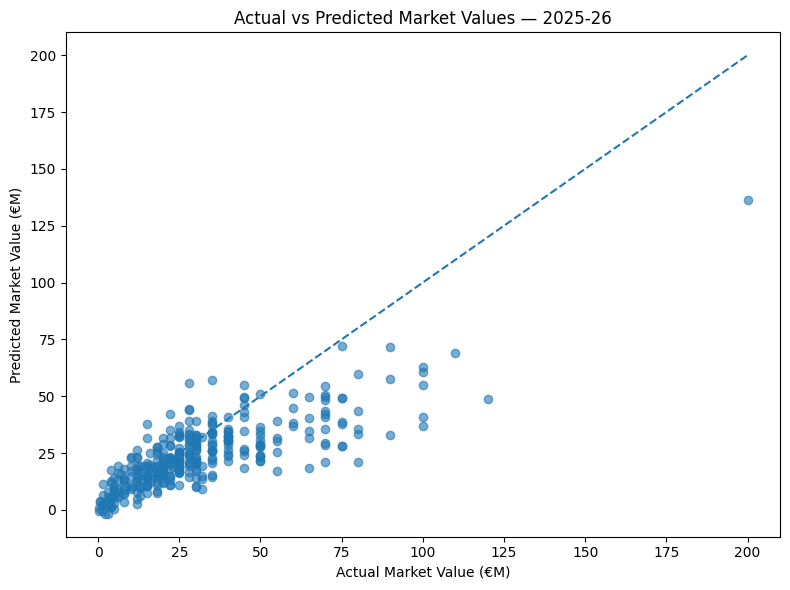

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_results["Actual_Value_M"],
    final_results["Predicted_Value_M"],
    alpha=0.6
)

max_value = max(
    final_results["Actual_Value_M"].max(),
    final_results["Predicted_Value_M"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Market Value (€M)")
plt.ylabel("Predicted Market Value (€M)")
plt.title("Actual vs Predicted Market Values — 2025-26")

plt.tight_layout()
plt.show()

In [ ]:
final_results.groupby("Position").agg(
    Players=("Player", "count"),
    MAE_M=("Absolute_Error_M", "mean")
).sort_values("MAE_M")

,Players,MAE_M
Position,,
Goalkeeper,24,4.292338
Defender,124,7.873936
Forward,79,12.988917
Midfielder,109,14.140239


In [ ]:
position_final_metrics = []

for pos in final_results["Position"].unique():

    subset = final_results[
        final_results["Position"] == pos
    ]

    actual = subset["Actual_Value_M"]
    predicted = subset["Predicted_Value_M"]

    position_final_metrics.append({
        "Position": pos,
        "Players": len(subset),

        "MAE (€M)": mean_absolute_error(
            actual,
            predicted
        ),

        "RMSE (€M)": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),

        "R²": r2_score(
            actual,
            predicted
        )
    })

final_position_metrics = pd.DataFrame(
    position_final_metrics
)

print(final_position_metrics)

     Position  Players   MAE (€M)  RMSE (€M)        R²
0     Forward       79  12.988917  18.740832  0.603459
1  Midfielder      109  14.140239  20.680784  0.370653
2    Defender      124   7.873936  11.731854  0.562391
3  Goalkeeper       24   4.292338   5.634894  0.810257


In [ ]:
import joblib

joblib.dump(
    final_global_model,
    "/content/final_global_model.pkl"
)

joblib.dump(
    final_defender_model,
    "/content/final_defender_model.pkl"
)

model_data.to_csv(
    "/content/premier_league_market_value_master.csv",
    index=False
)

print("Final models and dataset saved.")

Final models and dataset saved.


In [ ]:
final_results.to_csv(
    "/content/final_2025_26_predictions.csv",
    index=False
)

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log-Target Linear Regression",
        "Random Forest",
        "Global XGBoost",
        "Best Exploratory Position-Specific XGBoost",
        "Final Hybrid XGBoost"
    ],

    "MAE (€M)": [
        12.86,
        12.38,
        11.42,
        11.28,
        9.92,
        10.85
    ],

    "RMSE (€M)": [
        18.70,
        18.60,
        17.25,
        17.16,
        15.13,
        16.56
    ],

    "R²": [
        0.410,
        0.417,
        0.498,
        0.504,
        0.614,
        0.537
    ],

    "Evaluation Note": [
        "2025-26 test",
        "2025-26 test",
        "2025-26 test",
        "2025-26 test",
        "Exploratory result",
        "Validation-selected final architecture"
    ]
})

print(model_comparison)

                                        Model  MAE (€M)  RMSE (€M)     R²  \
0                           Linear Regression     12.86      18.70  0.410   
1                Log-Target Linear Regression     12.38      18.60  0.417   
2                               Random Forest     11.42      17.25  0.498   
3                              Global XGBoost     11.28      17.16  0.504   
4  Best Exploratory Position-Specific XGBoost      9.92      15.13  0.614   
5                        Final Hybrid XGBoost     10.85      16.56  0.537   

                          Evaluation Note  
0                            2025-26 test  
1                            2025-26 test  
2                            2025-26 test  
3                            2025-26 test  
4                      Exploratory result  
5  Validation-selected final architecture  


In [ ]:
model_comparison.to_csv(
    "/content/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


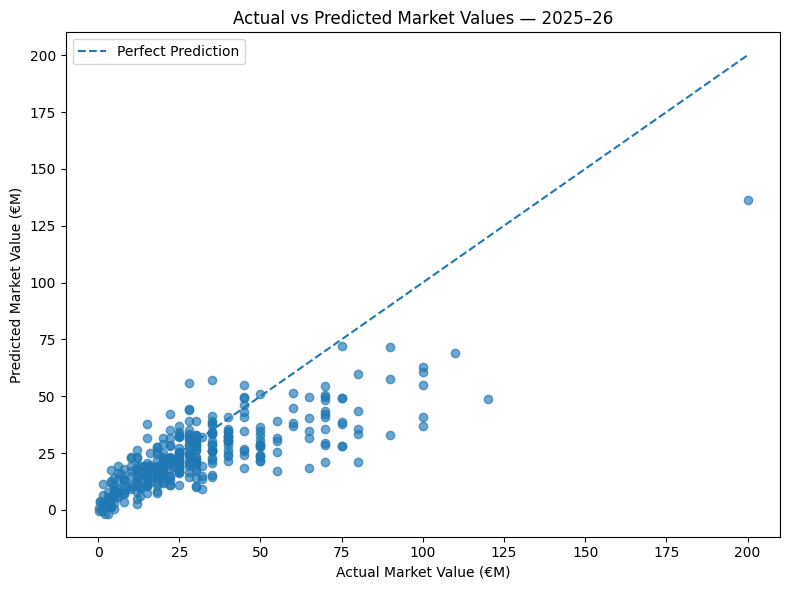

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_results["Actual_Value_M"],
    final_results["Predicted_Value_M"],
    alpha=0.65
)

max_value = max(
    final_results["Actual_Value_M"].max(),
    final_results["Predicted_Value_M"].max()
)

# Perfect prediction line
plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Market Value (€M)")
plt.ylabel("Predicted Market Value (€M)")
plt.title("Actual vs Predicted Market Values — 2025–26")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

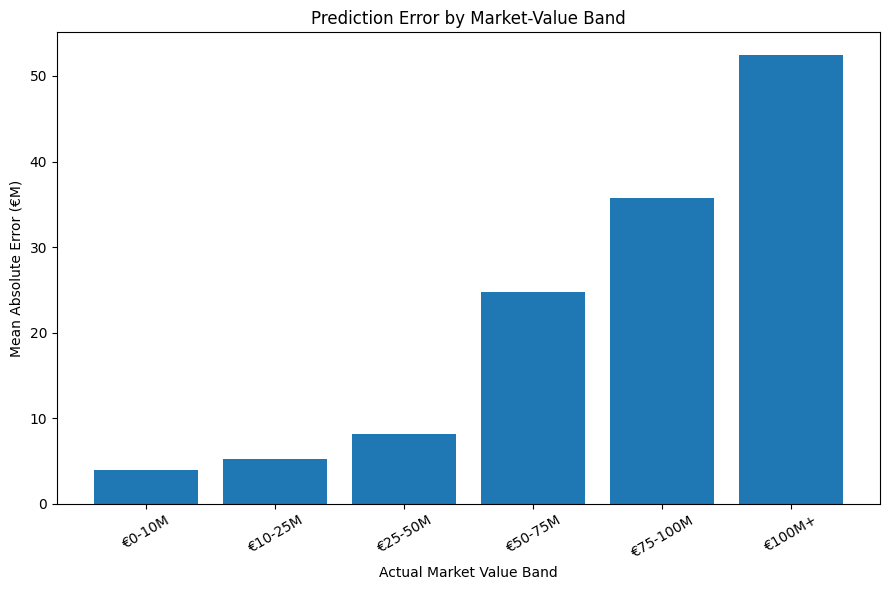

In [ ]:
band_plot = (
    final_results
    .groupby("Value_Band", observed=False)
    .agg(
        MAE=("Absolute_Error_M", "mean"),
        Actual_Avg=("Actual_Value_M", "mean"),
        Predicted_Avg=("Predicted_Value_M", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.bar(
    band_plot["Value_Band"].astype(str),
    band_plot["MAE"]
)

plt.xlabel("Actual Market Value Band")
plt.ylabel("Mean Absolute Error (€M)")
plt.title("Prediction Error by Market-Value Band")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "/content/error_by_value_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

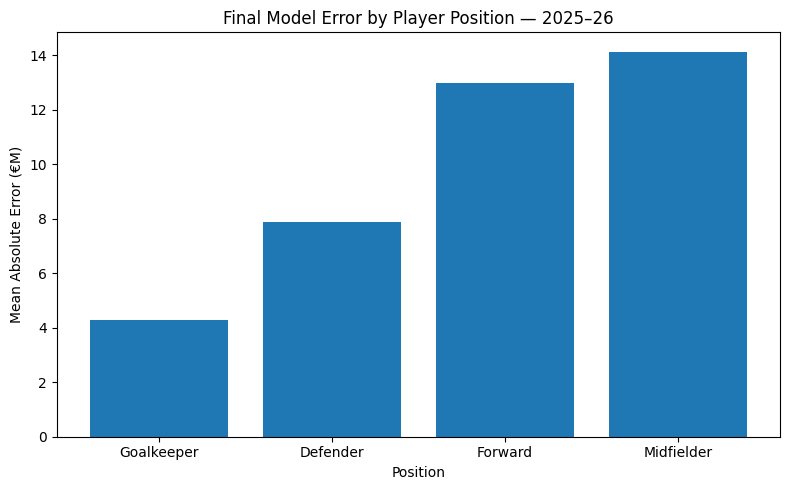

In [ ]:
position_plot = (
    final_position_metrics
    .sort_values("MAE (€M)")
    .copy()
)

plt.figure(figsize=(8, 5))

plt.bar(
    position_plot["Position"],
    position_plot["MAE (€M)"]
)

plt.xlabel("Position")
plt.ylabel("Mean Absolute Error (€M)")
plt.title("Final Model Error by Player Position — 2025–26")

plt.tight_layout()

plt.savefig(
    "/content/mae_by_position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

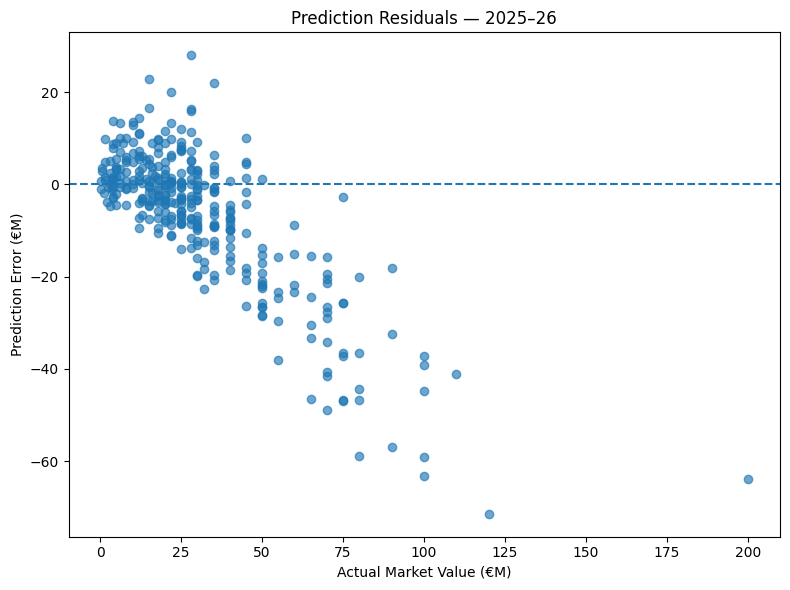

In [ ]:
final_results["Residual_M"] = (
    final_results["Predicted_Value_M"]
    - final_results["Actual_Value_M"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    final_results["Actual_Value_M"],
    final_results["Residual_M"],
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Actual Market Value (€M)")
plt.ylabel("Prediction Error (€M)")
plt.title("Prediction Residuals — 2025–26")

plt.tight_layout()

plt.savefig(
    "/content/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

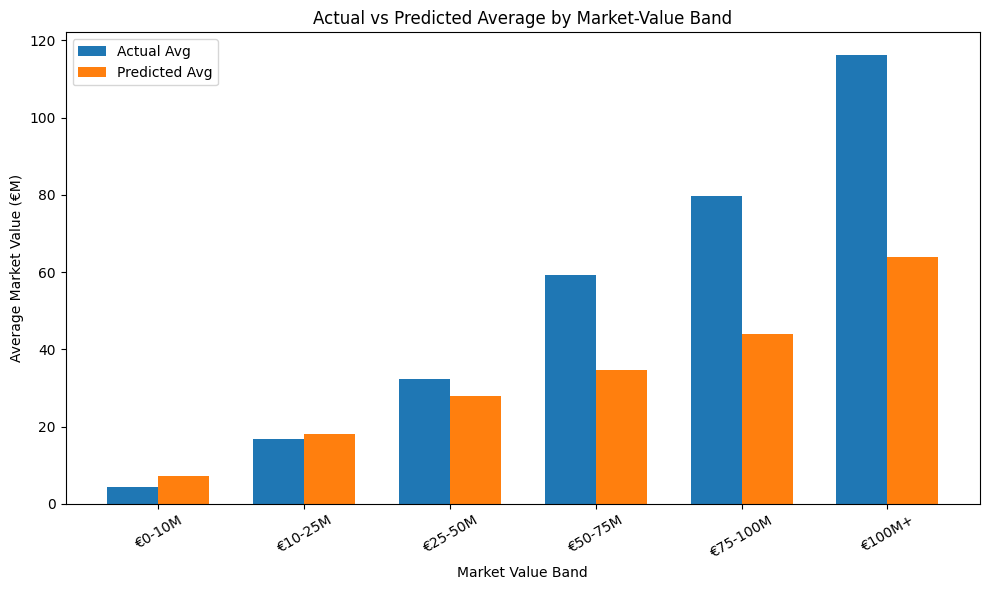

In [ ]:
band_comparison = (
    final_results
    .groupby("Value_Band", observed=False)
    .agg(
        Actual_Avg=("Actual_Value_M", "mean"),
        Predicted_Avg=("Predicted_Value_M", "mean")
    )
    .reset_index()
)

x = np.arange(len(band_comparison))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    band_comparison["Actual_Avg"],
    width,
    label="Actual Avg"
)

plt.bar(
    x + width/2,
    band_comparison["Predicted_Avg"],
    width,
    label="Predicted Avg"
)

plt.xticks(
    x,
    band_comparison["Value_Band"].astype(str),
    rotation=30
)

plt.xlabel("Market Value Band")
plt.ylabel("Average Market Value (€M)")
plt.title("Actual vs Predicted Average by Market-Value Band")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/actual_vs_predicted_by_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

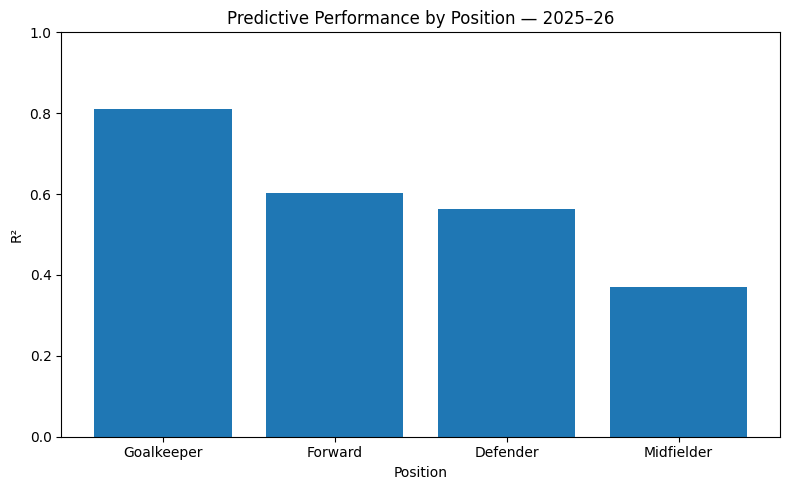

In [ ]:
position_r2 = (
    final_position_metrics
    .sort_values("R²", ascending=False)
    .copy()
)

plt.figure(figsize=(8, 5))

plt.bar(
    position_r2["Position"],
    position_r2["R²"]
)

plt.ylabel("R²")
plt.xlabel("Position")
plt.title("Predictive Performance by Position — 2025–26")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "/content/r2_by_position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Get fitted preprocessor and XGBoost model
global_preprocessor_fitted = (
    final_global_model.named_steps["preprocessor"]
)

global_model_xgb = (
    final_global_model.named_steps["model"]
)

# Get the ACTUAL feature names after preprocessing
global_feature_names = (
    global_preprocessor_fitted.get_feature_names_out()
)

# Make names easier to read
global_feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    .replace("position_", "")
    for name in global_feature_names
]

# Check lengths
print("Transformed features:", len(global_feature_names))
print(
    "Feature importances:",
    len(global_model_xgb.feature_importances_)
)

# Build feature importance table
global_importance_df = pd.DataFrame({
    "feature": global_feature_names,
    "importance": global_model_xgb.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(global_importance_df.head(15))

Transformed features: 27
Feature importances: 27
                              feature  importance
12  totalTouchesInOppositionBox_per90    0.116758
5                         goals_per90    0.092683
9               expectedAssists_per90    0.076414
3                              starts    0.064295
4                          timePlayed    0.062105
0                                 age    0.060759
1                         age_squared    0.052818
8                 expectedGoals_per90    0.046651
6                   goalAssists_per90    0.044339
22      totalLossesOfPossession_per90    0.043637
10      keyPassesAttemptAssists_per90    0.043456
24                            Forward    0.033643
21                   recoveries_per90    0.024772
7                    totalShots_per90    0.023772
17              totalClearances_per90    0.023154


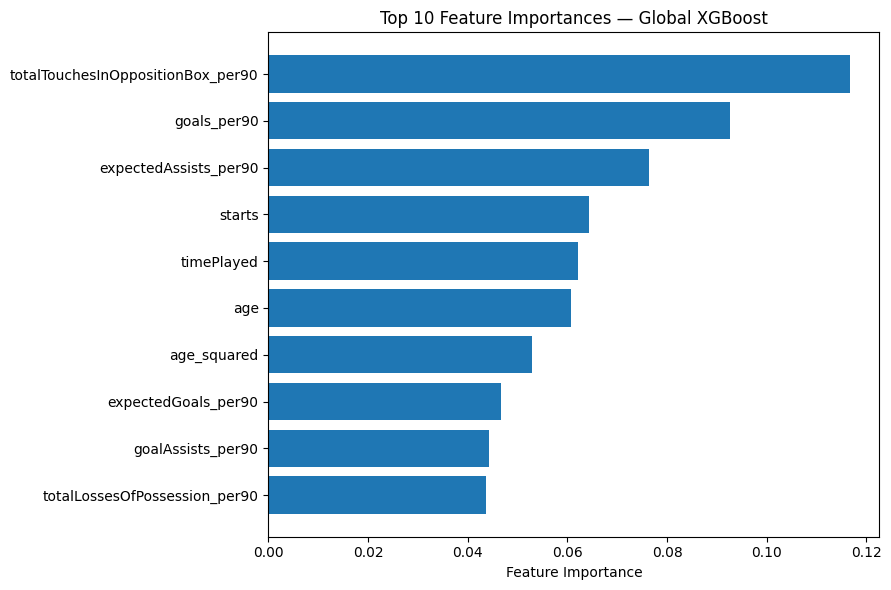

In [ ]:
global_top10 = global_importance_df.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    global_top10["feature"][::-1],
    global_top10["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances — Global XGBoost")

plt.tight_layout()

plt.savefig(
    "/content/global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
defender_importance_df = pd.DataFrame({
    "feature": defender_features,
    "importance": final_defender_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(defender_importance_df.head(15))

                                 feature  importance
19  successfulPassesOppositionHalf_per90    0.204820
17                     totalPasses_per90    0.074300
1                            age_squared    0.073760
0                                    age    0.069393
4                             timePlayed    0.069254
22                         touches_per90    0.056337
3                                 starts    0.051653
21                  openPlayPasses_per90    0.031565
29         totalLossesOfPossession_per90    0.028623
24                   opp_half_pass_share    0.028241
15                       aerial_win_rate    0.024733
12                  groundDuelsWon_per90    0.023288
18         successfulPassesOwnHalf_per90    0.019641
27                 expectedAssists_per90    0.018207
20            successfulLongPasses_per90    0.017964


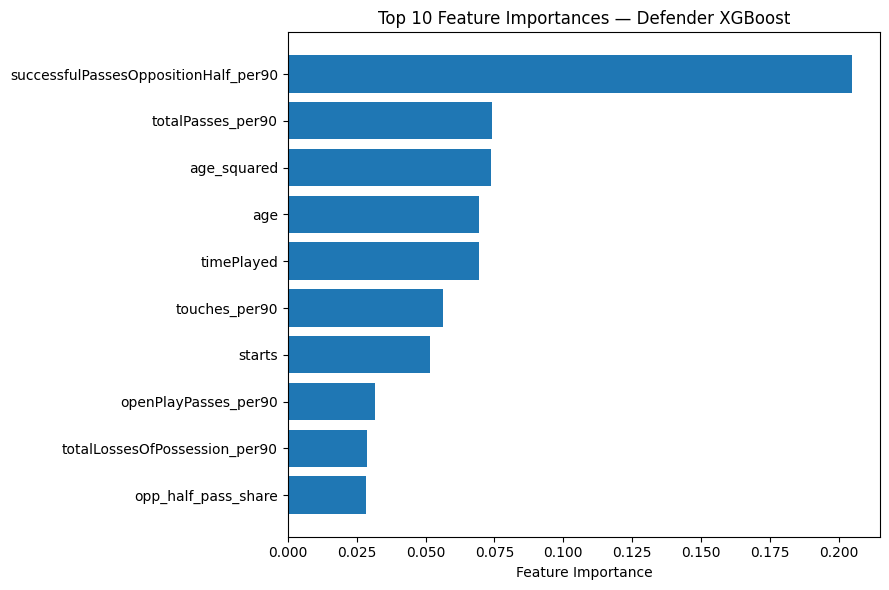

In [ ]:
defender_top10 = defender_importance_df.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    defender_top10["feature"][::-1],
    defender_top10["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances — Defender XGBoost")

plt.tight_layout()

plt.savefig(
    "/content/defender_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
import shutil

project_folder = "/content/premier_league_market_value_project"

os.makedirs(project_folder, exist_ok=True)

files_to_save = [
    # Models
    "/content/final_global_model.pkl",
    "/content/final_defender_model.pkl",

    # Data / results
    "/content/premier_league_market_value_master.csv",
    "/content/final_2025_26_predictions.csv",
    "/content/model_comparison.csv",

    # Plots
    "/content/actual_vs_predicted.png",
    "/content/residual_plot.png",
    "/content/actual_vs_predicted_by_band.png",
    "/content/r2_by_position.png",
    "/content/global_feature_importance.png",
    "/content/defender_feature_importance.png"
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, project_folder)
    else:
        print("Missing:", file)

print("Project files collected.")
print(os.listdir(project_folder))

Project files collected.
['global_feature_importance.png', 'final_global_model.pkl', 'defender_feature_importance.png', 'premier_league_market_value_master.csv', 'residual_plot.png', 'actual_vs_predicted.png', 'model_comparison.csv', 'final_defender_model.pkl', 'actual_vs_predicted_by_band.png', 'final_2025_26_predictions.csv', 'r2_by_position.png']


In [ ]:
shutil.make_archive(
    "/content/premier_league_market_value_project",
    "zip",
    project_folder
)

print("ZIP created.")

ZIP created.
